In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
from IPython.display import display
import scipy.stats as stats
from scipy.stats import linregress
from scipy.spatial.distance import pdist, squareform
import pingouin as pg
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter

In [2]:
stocks_info = {
    'NVDA': {'color': 'navy', 'file': 'data/NVIDIA Stock Price History.csv'},
    'AMD': {'color': 'orange', 'file': 'data/AMD Stock Price History.csv'},
    'AVGO': {'color': 'green', 'file': 'data/Broadcom Stock Price History.csv'},
    'INTC': {'color': 'skyblue', 'file': 'data/Intel Stock Price History.csv'},
}

NVDA - Loading data from data/NVIDIA Stock Price History.csv
AMD - Loading data from data/AMD Stock Price History.csv
AVGO - Loading data from data/Broadcom Stock Price History.csv
INTC - Loading data from data/Intel Stock Price History.csv


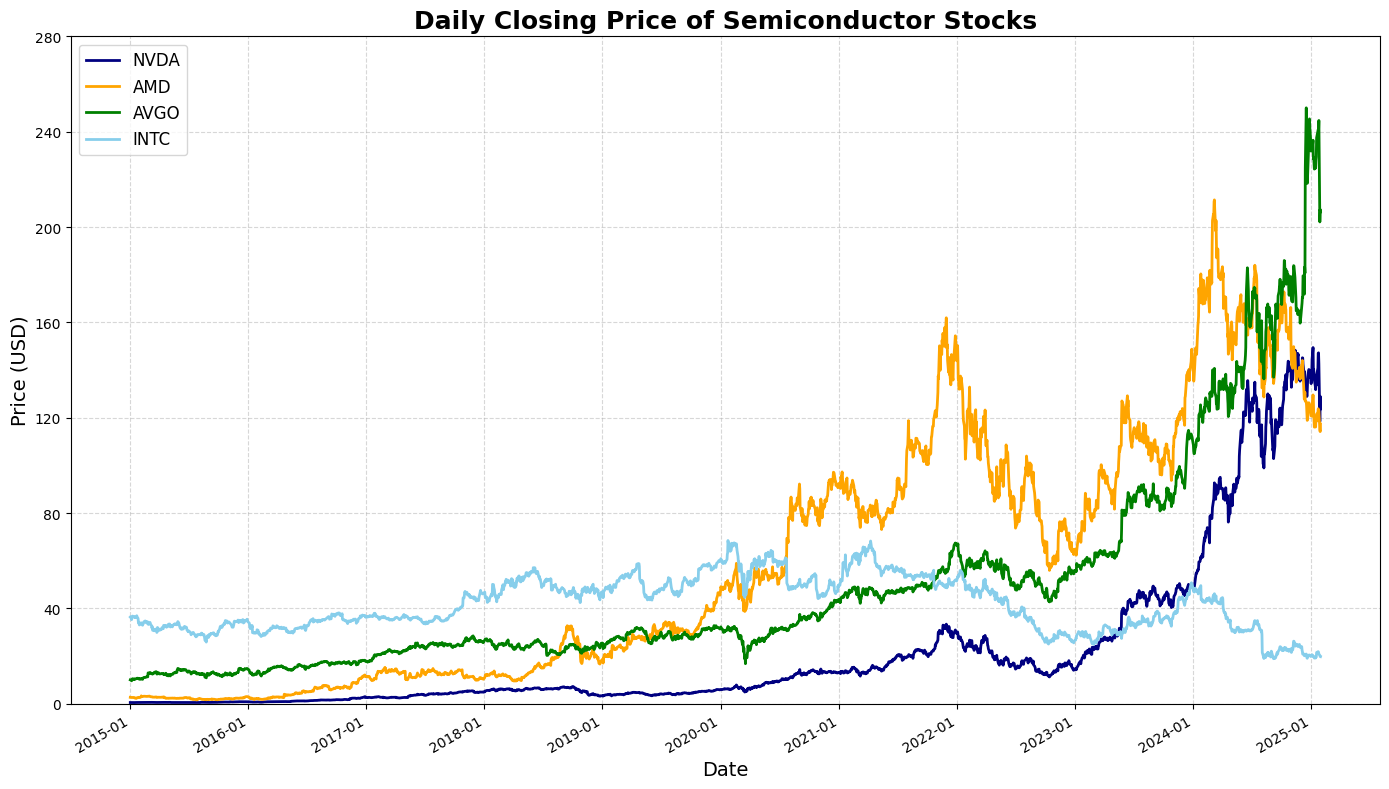

In [3]:
plt.figure(figsize=(14, 8))

for symbol, info in stocks_info.items():
    file_path = info['file']
    color = info['color']

    if not os.path.exists(file_path):
        print(f"File Error: {file_path} does not exists.")
        continue

    print(f"{symbol} - Loading data from {file_path}")

    df = pd.read_csv(file_path)

    df['Date'] = pd.to_datetime(df['Date'])

    df = df[df['Date'] != pd.to_datetime('2016-02-27')]

    df = df.sort_values('Date')

    df['Return'] = df['Price'].pct_change()

    if df['Price'].dtype == 'object':
        df['Price'] = df['Price'].str.replace(',', '').astype(float)

    df = df.sort_values('Date')

    plt.plot(df['Date'], df['Price'], label = symbol, color = color, linewidth = 2)

plt.title('Daily Closing Price of Semiconductor Stocks', fontsize = 18, fontweight = 'bold')
plt.xlabel('Date', fontsize = 14)
plt.ylabel('Price (USD)', fontsize = 14)
plt.legend(loc = 'upper left', fontsize = 12, frameon = True)
plt.grid(True, linestyle = '--', alpha = 0.5)

plt.ylim(0, 280)
plt.yticks(np.arange(0, 281, 40))

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

In [4]:
assets_info = {
    'DJI': {'color': 'navy', 'file': 'data/Dow Jones Industrial Average Historical Data.csv', 'label': 'Index Value',
            },
    'DJI_mod': {'color': 'navy', 'file': 'data/Dow Jones Industrial Average Historical Data.csv', 'label': 'Index Value',
            'ylim': (0, 15000), 'ystep': 2500},
    'XAU': {'color': 'navy', 'file': 'data/XAU_USD Historical Data.csv', 'label': 'Price (USD per ounce)',
            'ylim': (0, 3000), 'ystep': 500},
    'EUR': {'color': 'navy', 'file': 'data/EUR_USD Historical Data.csv', 'label': 'Price (USD per EUR)',
            'ylim': (0.8, 1.4), 'ystep': 0.1},
    'WTI': {'color': 'navy', 'file': 'data/WTI_USD Historical Data.csv', 'label': 'Price (USD/bbl)',
            'ylim': (0, 140), 'ystep': 20},
    'BTC': {'color': 'navy', 'file': 'data/Bitcoin Historical Data.csv', 'label': 'Price (USD/BTC)',
            'ylim': (0, 120000), 'ystep': 20000},
}

DJI - Loading data from data/Dow Jones Industrial Average Historical Data.csv
DJI_mod - Loading data from data/Dow Jones Industrial Average Historical Data.csv
XAU - Loading data from data/XAU_USD Historical Data.csv
EUR - Loading data from data/EUR_USD Historical Data.csv
WTI - Loading data from data/WTI_USD Historical Data.csv
BTC - Loading data from data/Bitcoin Historical Data.csv


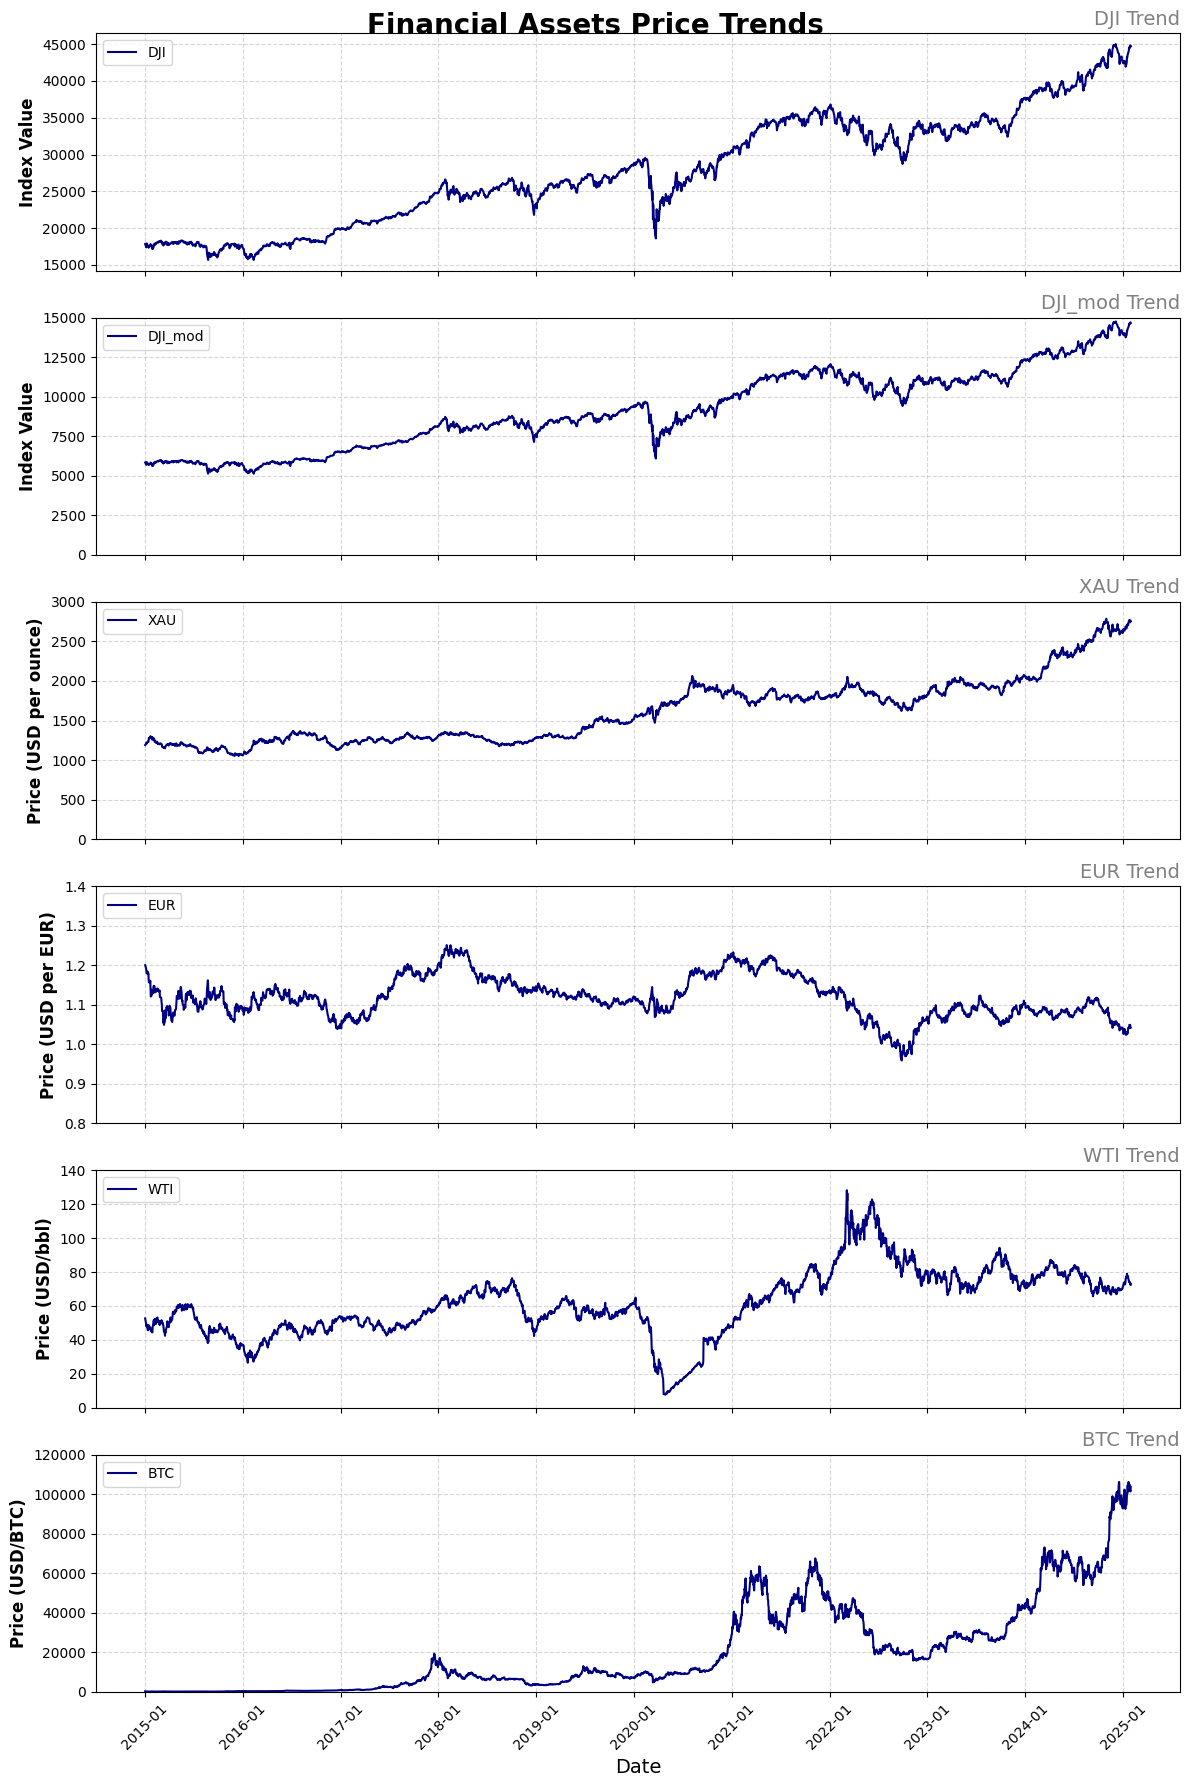

In [5]:
fig, axes = plt.subplots(nrows = 6, ncols = 1, figsize = (12, 20), sharex = True)

for i, (symbol, info) in enumerate(assets_info.items()):
    ax = axes[i]
    file_path = info['file']

    if not os.path.exists(file_path):
        print((f"File Error: {file_path} does not exists."))
        ax.text(0.5, 0.5, f"{symbol} data not found", ha = 'center', va = 'center')
        continue

    print(f"{symbol} - Loading data from {file_path}")

    df = pd.read_csv(file_path)

    df['Date'] = pd.to_datetime(df['Date'])

    price_col = 'Price' if 'Price' in df.columns else 'Close'

    if df[price_col].dtype == 'object':
        df[price_col] = df[price_col].str.replace(',', '').astype(float)

    df = df.sort_values('Date')

    if symbol == 'DJI_mod':
        df[price_col] = df[price_col] / 3.05

    ax.plot(df['Date'], df[price_col], label = symbol, color = info['color'], linewidth = 1.5)
    
    if 'ylim' in info:
        ymin, ymax = info['ylim']
        ax.set_ylim(ymin, ymax)

        if 'ystep' in info:
            step = info['ystep']
            ticks = np.arange(ymin, ymax + (step/1000), step)
            ax.set_yticks(ticks)

    ax.set_ylabel(info['label'], fontsize = 12, fontweight = 'bold')
    ax.legend(loc = 'upper left', fontsize = 10, frameon = True)
    ax.grid(True, linestyle = '--', alpha = 0.5)

    ax.set_title(f"{symbol} Trend", fontsize = 14, loc = 'right', color = 'gray')

plt.xlabel('Date', fontsize = 14)
plt.xticks(rotation = 45)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].xaxis.set_major_locator(mdates.YearLocator())

plt.suptitle('Financial Assets Price Trends', fontsize = 20, fontweight = 'bold', y = 0.92)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [6]:
file_map = {
    # Semiconductor Stocks
    'NVDA': 'data/NVIDIA Stock Price History.csv',
    'AMD': 'data/AMD Stock Price History.csv',
    'AVGO': 'data/Broadcom Stock Price History.csv',
    'INTC': 'data/Intel Stock Price History.csv',
    # Financial Assets
    'DJI': 'data/Dow Jones Industrial Average Historical Data.csv',
    'XAU': 'data/XAU_USD Historical Data.csv',
    'EUR': 'data/EUR_USD Historical Data.csv',
    'WTI': 'data/WTI_USD Historical Data.csv',
    'BTC': 'data/Bitcoin Historical Data.csv',
}


,NVDA,AMD,AVGO,INTC,DJI,XAU,EUR,WTI,BTC
Mean,0.22%,0.15%,0.12%,-0.02%,0.04%,0.03%,-0.01%,0.01%,0.23%
Std Dev,3.08%,3.63%,2.38%,2.28%,1.11%,0.89%,0.50%,2.89%,4.39%
Min,-20.79%,-27.75%,-22.19%,-30.19%,-13.84%,-5.90%,-2.40%,-41.77%,-49.73%
Max,26.37%,42.06%,21.86%,17.83%,10.76%,4.69%,3.04%,40.35%,24.08%


,NVDA,AMD,AVGO,INTC,DJI,XAU,EUR,WTI,BTC
NVDA,1.00,0.59,0.60,0.47,0.52,0.01,0.04,0.12,0.20
AMD,0.59,1.00,0.45,0.38,0.42,0.03,0.07,0.12,0.14
AVGO,0.60,0.45,1.00,0.50,0.58,0.03,0.05,0.18,0.15
INTC,0.47,0.38,0.50,1.00,0.58,0.04,0.02,0.16,0.16
DJI,0.52,0.42,0.58,0.58,1.00,0.01,0.08,0.28,0.21
XAU,0.01,0.03,0.03,0.04,0.01,1.00,0.37,0.08,0.09
EUR,0.04,0.07,0.05,0.02,0.08,0.37,1.00,0.04,0.06
WTI,0.12,0.12,0.18,0.16,0.28,0.08,0.04,1.00,0.05
BTC,0.20,0.14,0.15,0.16,0.21,0.09,0.06,0.05,1.00


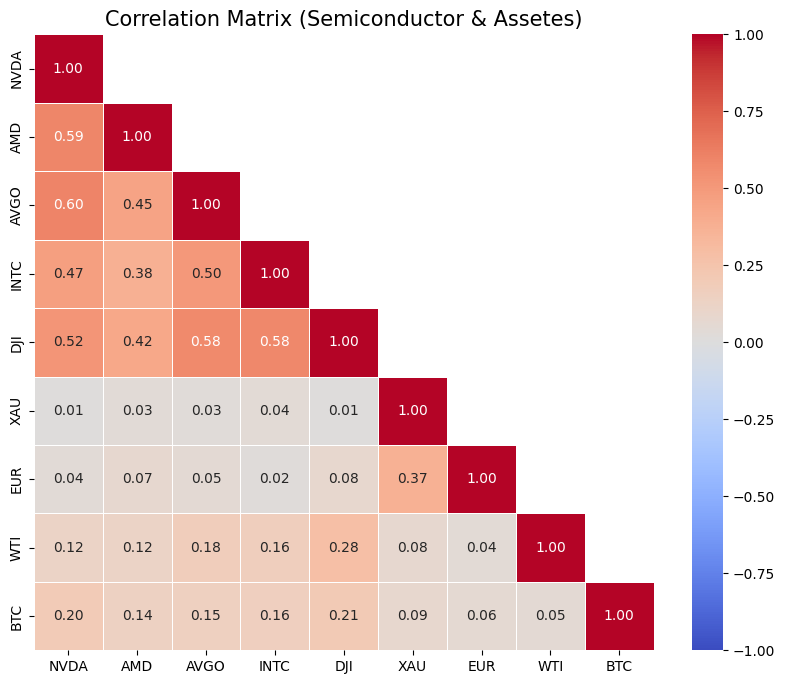

In [7]:
def load_data(file_map):
    df = pd.DataFrame()

    for symbol, file_path in file_map.items():
        if not os.path.exists(file_path):
            print(f"File Error: {file_path} does not exists.")
            continue

        temp_df = pd.read_csv(file_path)
        temp_df['Date'] = pd.to_datetime(temp_df['Date'])

        col_name = 'Price' if 'Price' in temp_df.columns else 'Close'
        if temp_df[col_name].dtype == 'object':
            temp_df[col_name] = temp_df[col_name].str.replace(',', '').astype(float)

        temp_df = temp_df.sort_values('Date').set_index('Date')
        temp_df = temp_df[[col_name]].rename(columns={col_name: symbol})

        if df.empty:
            df = temp_df
        else:
            df = df.join(temp_df, how = 'inner')
    return df

df_price = load_data(file_map)

log_returns_pct = np.log(df_price / df_price.shift(1)).dropna()
log_returns_pct = log_returns_pct * 100

table1 = log_returns_pct.describe().T[['mean', 'std', 'min', 'max']]

table1.columns = ['Mean', 'Std Dev', 'Min', 'Max']

table1 = table1.T

display(table1.style.format("{:.2f}%"))
print("="*50)

table2 = log_returns_pct.corr(method = 'pearson')
display(table2.style.background_gradient(cmap = 'coolwarm', axis = None).format("{:.2f}"))

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(table2, dtype = bool), k = 1)
sns.heatmap(table2, annot = True, fmt = ".2f", cmap = 'coolwarm', linewidth = 0.5, vmin = -1, vmax = 1, center = 0, mask = mask)
plt.title('Correlation Matrix (Semiconductor & Assetes)', fontsize = 15)
plt.show()

In [8]:
def manual_mean(data):
    if len(data) == 0:
        return np.nan
    return sum(data) / len(data)

def manual_std(data, is_sample=True):
    if len(data) < 2:
        return 0.0 if len(data) == 1 else np.nan
    mean = manual_mean(data)
    squared_diffs = [(x - mean) ** 2 for x in data]
    variance = sum(squared_diffs) / (len(data) - 1 if is_sample else len(data))
    return variance ** 0.5

def manual_min(data):
    return min(data) if len(data) > 0 else np.nan

def manual_max(data):
    return max(data) if len(data) > 0 else np.nan 


mean = log_returns_pct.apply(manual_mean)
std = log_returns_pct.apply(manual_std)
min_val = log_returns_pct.apply(manual_min)
max_val = log_returns_pct.apply(manual_max)

table_manual = pd.DataFrame({
    'Mean': mean,
    'Std Dev': std,
    'Min': min_val,
    'Max': max_val
})

table_manual = table_manual.T
display(table_manual.style.format("{:.2f}%"))

,NVDA,AMD,AVGO,INTC,DJI,XAU,EUR,WTI,BTC
Mean,0.22%,0.15%,0.12%,-0.02%,0.04%,0.03%,-0.01%,0.01%,0.23%
Std Dev,3.08%,3.63%,2.38%,2.28%,1.11%,0.89%,0.50%,2.89%,4.39%
Min,-20.79%,-27.75%,-22.19%,-30.19%,-13.84%,-5.90%,-2.40%,-41.77%,-49.73%
Max,26.37%,42.06%,21.86%,17.83%,10.76%,4.69%,3.04%,40.35%,24.08%


Removing Market Factor (DJI) from all assets...
🚀 Calculating DCCA Rho Matrix (Scale n=10, Poly=3)...

[DCCA Coefficient Matrix (n=10)]


,NVDA,AMD,AVGO,INTC,DJI,XAU,EUR,WTI,BTC
NVDA,1.0000,0.2394,0.1965,0.0759,0.0402,0.0963,0.0599,-0.0158,0.0543
AMD,0.2394,1.0000,0.0751,0.0911,0.0424,0.0261,0.0112,-0.0173,0.0020
AVGO,0.1965,0.0751,1.0000,0.1261,0.0733,0.0591,0.0900,-0.0230,-0.0174
INTC,0.0759,0.0911,0.1261,1.0000,0.0064,-0.0007,-0.0026,-0.0173,0.0054
DJI,0.0402,0.0424,0.0733,0.0064,1.0000,0.1406,0.1000,0.0460,0.0744
XAU,0.0963,0.0261,0.0591,-0.0007,0.1406,1.0000,0.1653,0.0198,0.0449
EUR,0.0599,0.0112,0.0900,-0.0026,0.1000,0.1653,1.0000,0.0465,-0.0696
WTI,-0.0158,-0.0173,-0.0230,-0.0173,0.0460,0.0198,0.0465,1.0000,-0.0121
BTC,0.0543,0.0020,-0.0174,0.0054,0.0744,0.0449,-0.0696,-0.0121,1.0000


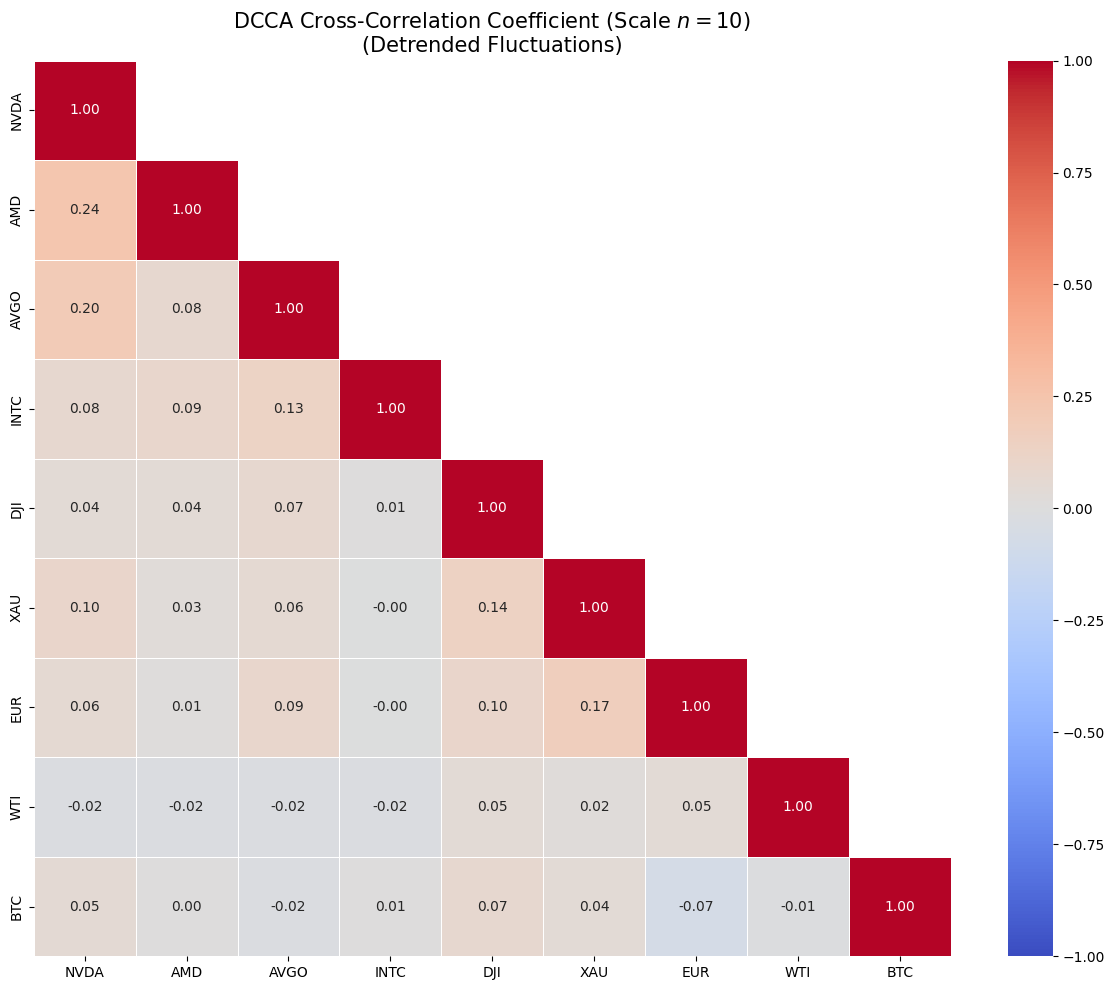

In [9]:
market_index = 'DJI'
if market_index not in log_returns_pct.columns:
    print(f"Error: {market_index} not found in data.")
    # DJI 없으면 그냥 진행 (값 높게 나옴)
    residuals_df = log_returns_pct.copy()
else:
    print(f"Removing Market Factor ({market_index}) from all assets...")
    residuals_df = pd.DataFrame(index=log_returns_pct.index)
    
    market_ret = log_returns_pct[market_index]
    
    for col in log_returns_pct.columns:
        if col == market_index:
            residuals_df[col] = log_returns_pct[col] # 시장지수는 그대로 둠 (나중에 1로 처리)
            continue
            
        # Linear Regression: Asset = alpha + beta * Market + epsilon(Residual)
        slope, intercept, r_value, p_value, std_err = linregress(market_ret, log_returns_pct[col])
        
        # 잔차(Residual) 계산 = 실제값 - 예측값
        # 이것이 바로 '시장 빨'을 뺀 순수 변동성
        residuals_df[col] = log_returns_pct[col] - (slope * market_ret + intercept)

# 절대값 적용 (Volatility)
data_input = np.abs(residuals_df)


def calculate_dcca_rho(series1, series2, scale, poly_order = 3):
    X = np.cumsum(series1 - np.mean(series1))
    Y = np.cumsum(series2 - np.mean(series2))
    
    N = len(X)
    segments = N // scale
    
    F2_DFA_x = 0
    F2_DFA_y = 0
    F2_DCCA = 0
    
    for i in range(segments):
        idx_start = i * scale
        idx_end = idx_start + scale
        
        x_seg = X[idx_start:idx_end]
        y_seg = Y[idx_start:idx_end]
        t = np.arange(scale)
        
        # 추세 제거 (Detrending) - polyfit
        coef_x = np.polyfit(t, x_seg, poly_order)
        trend_x = np.polyval(coef_x, t)
        
        coef_y = np.polyfit(t, y_seg, poly_order)
        trend_y = np.polyval(coef_y, t)
        
        resid_x = x_seg - trend_x
        resid_y = y_seg - trend_y
        
        # 분산(DFA) 및 공분산(DCCA) 누적
        F2_DFA_x += np.sum(resid_x ** 2) / scale
        F2_DFA_y += np.sum(resid_y ** 2) / scale
        F2_DCCA += np.sum(resid_x * resid_y) / scale
        
    # 평균 계산
    F2_DFA_x /= segments
    F2_DFA_y /= segments
    F2_DCCA /= segments
    
    # Rho 계산 (Correlation 공식: Cov / (std_x * std_y))
    if F2_DFA_x == 0 or F2_DFA_y == 0:
        return 0
        
    rho = F2_DCCA / np.sqrt(F2_DFA_x * F2_DFA_y)
    return rho

# ---------------------------------------------------------
# 3. 9x9 행렬 계산 실행
# ---------------------------------------------------------
# 분석 대상 변수 리스트 (9개)
financial_assets = ['DJI', 'XAU', 'EUR', 'WTI', 'BTC']
semi_stocks = ['NVDA', 'AMD', 'AVGO', 'INTC']
all_vars = semi_stocks + financial_assets

valid_vars = [col for col in all_vars if col in data_input.columns]

# 파라미터 설정
scale_n = 10  # [핵심] 스케일을 작게(10~30) 잡을수록 단기 변동만 남아 값이 작아짐 (논문값 재현용)
poly_order = 3 # 보통 DCCA 계수는 1차(Linear)나 2차 추세 제거를 많이 씀

print(f"🚀 Calculating DCCA Rho Matrix (Scale n={scale_n}, Poly={poly_order})...")

rho_matrix = pd.DataFrame(index=valid_vars, columns=valid_vars, dtype=float)

for var_a in valid_vars:
    for var_b in valid_vars:
        if var_a == var_b:
            rho_matrix.loc[var_a, var_b] = 1.0
        elif var_a > var_b: # 대칭 행렬이므로 절반만 계산 (속도 향상)
            continue
        else:
            rho = calculate_dcca_rho(
                data_input[var_a].values, 
                data_input[var_b].values, 
                scale_n, 
                poly_order
            )
            rho_matrix.loc[var_a, var_b] = rho
            rho_matrix.loc[var_b, var_a] = rho # 대칭 복사

# ---------------------------------------------------------
# 4. 결과 출력 및 시각화
# ---------------------------------------------------------
print(f"\n[DCCA Coefficient Matrix (n={scale_n})]")
display(rho_matrix.style.background_gradient(cmap='coolwarm', axis=None).format("{:.4f}"))

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(rho_matrix, dtype=bool), k = 1) # 대각선 위 가리기

sns.heatmap(rho_matrix.astype(float), annot=True, fmt=".2f", cmap='coolwarm', 
            linewidth=0.5, vmin=-1, vmax=1, center=0, mask=mask)

plt.title(f'DCCA Cross-Correlation Coefficient (Scale $n={scale_n}$)\n(Detrended Fluctuations)', fontsize=15)
plt.tight_layout()
plt.show()

,NVDA,AMD,AVGO,INTC,DJI,XAU,EUR,WTI,BTC
NVDA,1.00,0.27,0.26,0.10,0.16,0.07,-0.04,-0.03,0.04
AMD,0.27,1.00,0.03,0.08,0.09,-0.01,0.02,0.01,0.01
AVGO,0.26,0.03,1.00,0.15,0.25,0.01,0.08,0.04,-0.02
INTC,0.10,0.08,0.15,1.00,0.30,-0.03,0.00,-0.02,0.02
DJI,0.16,0.09,0.25,0.30,1.00,0.13,0.08,0.22,0.11
XAU,0.07,-0.01,0.01,-0.03,0.13,1.00,0.19,0.03,0.05
EUR,-0.04,0.02,0.08,0.00,0.08,0.19,1.00,0.07,0.02
WTI,-0.03,0.01,0.04,-0.02,0.22,0.03,0.07,1.00,-0.03
BTC,0.04,0.01,-0.02,0.02,0.11,0.05,0.02,-0.03,1.00


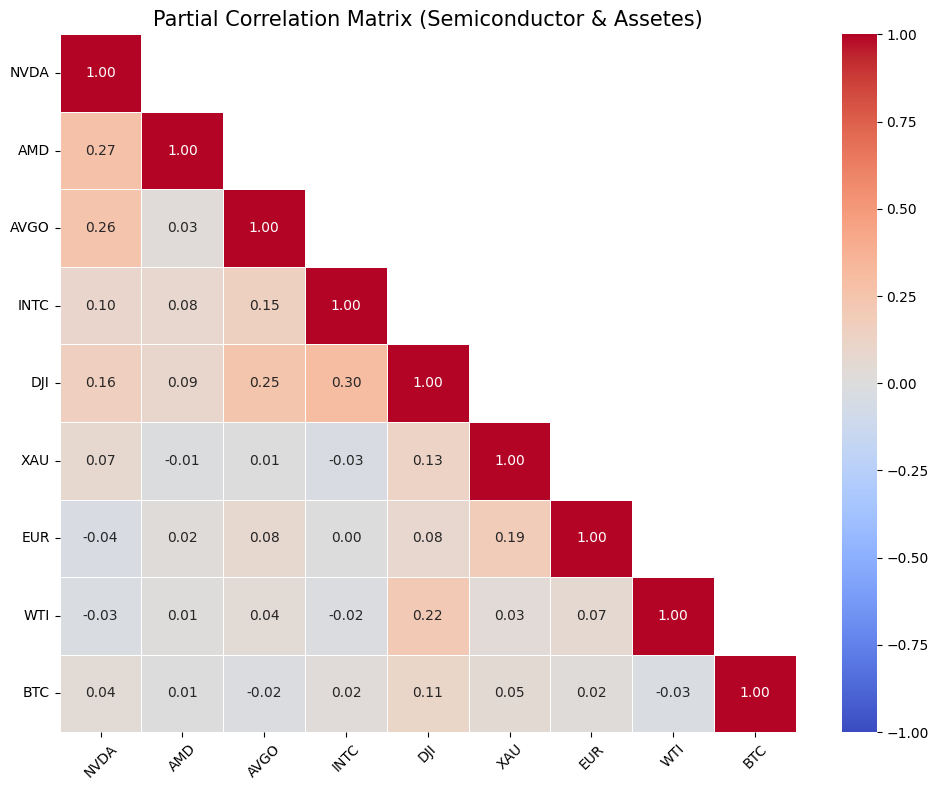

In [10]:
semi_stock = ['NVDA', 'AMD', 'AVGO', 'INTC']
financial_assets = ['DJI', 'XAU', 'EUR', 'WTI', 'BTC']

log_returns_abs = np.abs(log_returns_pct)
valid_vars = semi_stock + financial_assets

partial_corr_matrix = pd.DataFrame(index = valid_vars, columns = valid_vars, dtype = float)

for var_a in valid_vars:
    for var_b in valid_vars:
        if var_a == var_b:
            partial_corr_matrix.loc[var_a, var_b] = 1.0
        else:
            covars = [x for x in valid_vars if x != var_a and x != var_b]
            
            try:
                stats_pg = pg.partial_corr(data = log_returns_abs, x = var_a, y = var_b, covar = covars)
                partial_corr_matrix.loc[var_a, var_b] = stats_pg['r'].values[0]
            except Exception as e:
                partial_corr_matrix.loc[var_a, var_b] = np.nan
              
              
display(partial_corr_matrix.style.background_gradient(cmap = 'coolwarm', axis = None).format("{:.2f}"))

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(partial_corr_matrix, dtype = bool), k = 1)

sns.heatmap(partial_corr_matrix.astype(float), annot = True, fmt = ".2f", cmap = 'coolwarm', linewidth = 0.5, vmin = -1, vmax = 1, center = 0, mask = mask)

plt.title('Partial Correlation Matrix (Semiconductor & Assetes)', fontsize = 15)
plt.xticks(rotation = 45)
plt.yticks(rotation = 0)
plt.tight_layout()
plt.show()

,NVDA,AMD,AVGO,INTC,DJI,XAU,EUR,WTI,BTC
NVDA,1.0000,0.4115,0.4091,0.3633,0.3583,0.1241,0.0947,0.1091,0.0929
AMD,0.4115,1.0000,0.2655,0.2656,0.2553,0.0657,0.0798,0.0985,0.0495
AVGO,0.4091,0.2655,1.0000,0.3837,0.3964,0.1192,0.1358,0.1445,0.0592
INTC,0.3633,0.2656,0.3837,1.0000,0.3997,0.0835,0.0870,0.1001,0.0698
DJI,0.3583,0.2553,0.3964,0.3997,1.0000,0.1710,0.1673,0.2317,0.0858
XAU,0.1241,0.0657,0.1192,0.0835,0.1710,1.0000,0.2109,0.1314,0.0643
EUR,0.0947,0.0798,0.1358,0.0870,0.1673,0.2109,1.0000,0.1422,0.0463
WTI,0.1091,0.0985,0.1445,0.1001,0.2317,0.1314,0.1422,1.0000,0.0477
BTC,0.0929,0.0495,0.0592,0.0698,0.0858,0.0643,0.0463,0.0477,1.0000


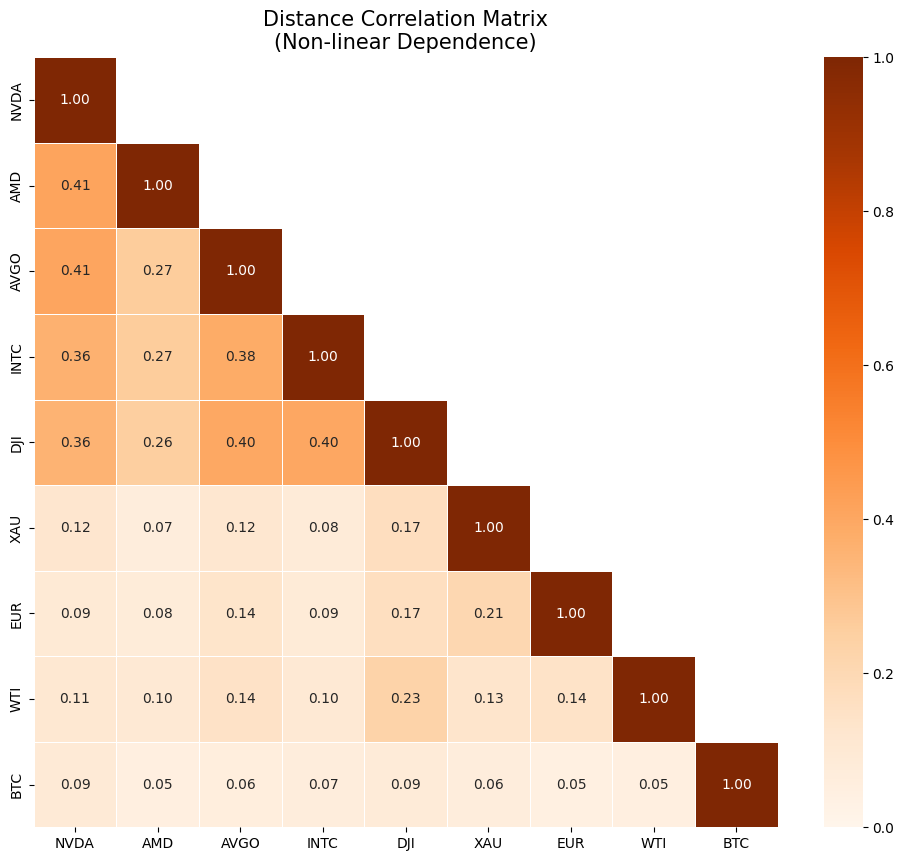

In [11]:
semi_stock = ['NVDA', 'AMD', 'AVGO', 'INTC']
financial_assets = ['DJI', 'XAU', 'EUR', 'WTI', 'BTC']

valid_vars = semi_stock + financial_assets

def dist_corr(X, Y):
    X = X[:, None]
    Y = Y[:, None]
    
    A = squareform(pdist(X))
    B = squareform(pdist(Y))
    
    A_mean_row = A.mean(axis = 0, keepdims = True)
    A_mean_col = A.mean(axis = 1, keepdims = True)
    A_mean_total = A.mean()
    A_centered = A - A_mean_row - A_mean_col + A_mean_total
    
    B_mean_row = B.mean(axis = 0, keepdims = True)
    B_mean_col = B.mean(axis = 1, keepdims = True)
    B_mean_total = B.mean()
    B_centered = B - B_mean_row - B_mean_col + B_mean_total
    
    dCov2_xy = np.mean(A_centered * B_centered)
    dVal_x = np.mean(A_centered * A_centered)
    dVal_y = np.mean(B_centered * B_centered)
    
    if dVal_x == 0 or dVal_y == 0:
        return 0
    else:
        return np.sqrt(dCov2_xy / np.sqrt(dVal_x * dVal_y))
    


valid_vars = [col for col in valid_vars if col in log_returns_abs.columns]

dcor_matrix = pd.DataFrame(index = valid_vars, columns = valid_vars, dtype = float)

for col_a in valid_vars:
    for col_b in valid_vars:
        if col_a == col_b:
            dcor_matrix.loc[col_a, col_b] = 1.0
        elif col_a > col_b:
            continue
        else:
            val = dist_corr(log_returns_abs[col_a].values, log_returns_abs[col_b].values)
            dcor_matrix.loc[col_a, col_b] = val
            dcor_matrix.loc[col_b, col_a] = val
            
display(dcor_matrix.style.background_gradient(cmap='Oranges', axis=None).format("{:.4f}"))

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(dcor_matrix, dtype=bool), k = 1)
sns.heatmap(dcor_matrix.astype(float), annot=True, fmt=".2f", cmap='Oranges', 
            linewidth=0.5, vmin=0, vmax=1, mask=mask)
plt.title('Distance Correlation Matrix\n(Non-linear Dependence)', fontsize=15)
plt.show()

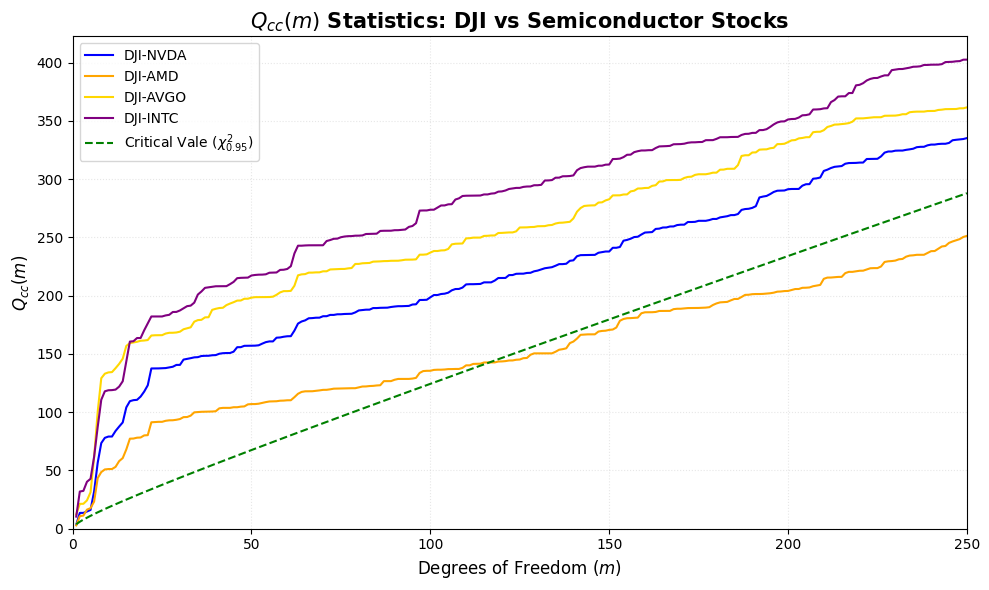

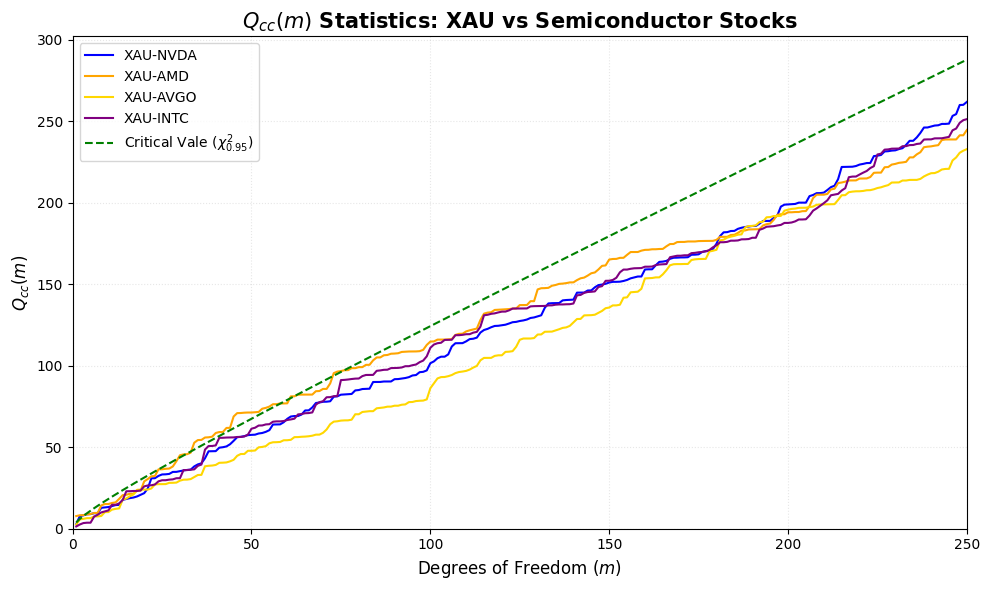

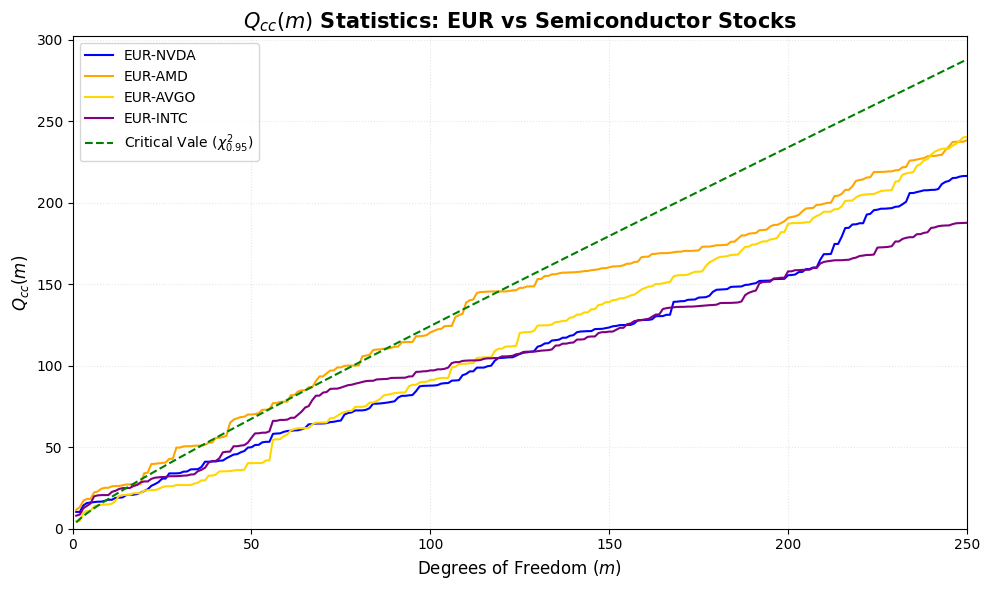

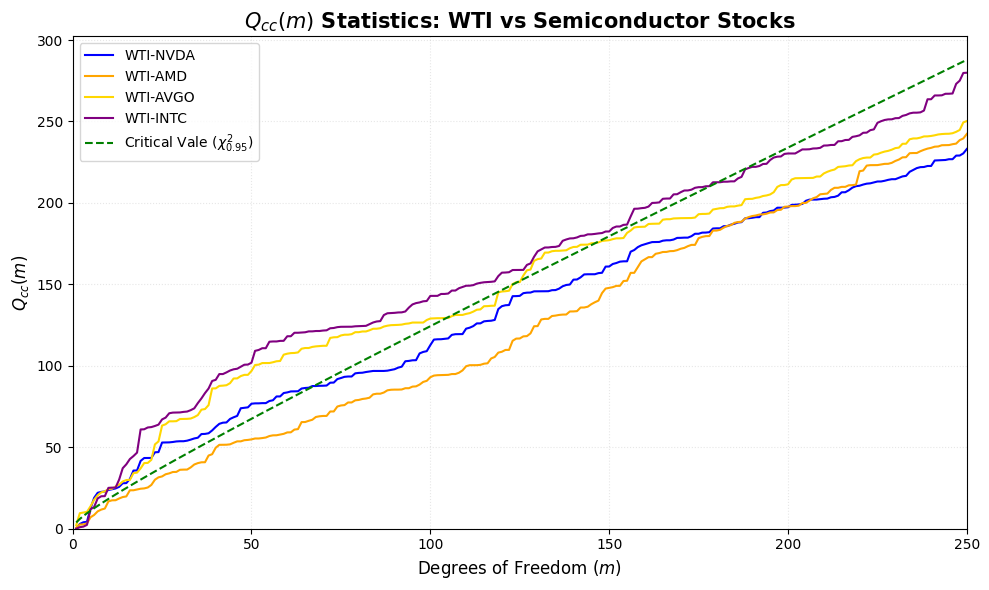

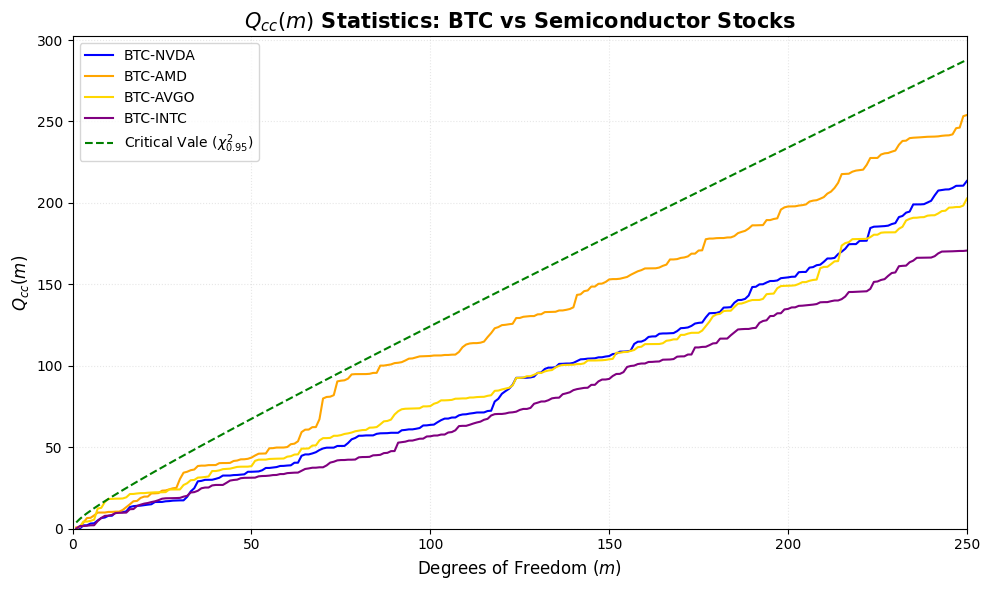

In [12]:
df_price = load_data(file_map)

log_returns = np.log(df_price / df_price.shift(1)).dropna()

def calculate_qcc(series_x, series_y, max_m = 250):
    common_df = pd.concat([series_x, series_y], axis = 1).dropna()
    x = common_df.iloc[:, 0].values
    y = common_df.iloc[:, 1].values
    N = len(x)

    if N < max_m + 10: return None
    q_stat_list = []
    cumulative_sum = 0
    
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    x_std = np.std(x)
    y_std = np.std(y)
    
    denom = N * x_std * y_std

    for i in range(1, max_m + 1):
        x_lag = x[i:]
        y_lag = y[:-i]
        
        numerator = np.sum((x_lag - x_mean) * (y_lag - y_mean))
        
        rho_i = numerator / denom 
        
        cumulative_sum += (rho_i ** 2) / (N - i)
        
        q_stat = N * (N + 2) * cumulative_sum
        q_stat_list.append(q_stat)

    return q_stat_list

max_m_val = 250
m_range = range(1, max_m_val + 1)

critical_values = [stats.chi2.ppf(0.95, df = m) for m in m_range]

colors = {'NVDA': 'blue', 'AMD': 'orange', 'AVGO': 'gold', 'INTC': 'purple'}

for asset in financial_assets:
    if asset not in log_returns.columns: continue

    plt.figure(figsize = (10, 6))
    asset_data = log_returns[asset]
    plot_exists = False

    for stock in semi_stock:
        if stock not in log_returns.columns: continue

        q_stats = calculate_qcc(asset_data, log_returns[stock], max_m = max_m_val)

        if q_stats is not None:
            plt.plot(m_range, q_stats, label = f'{asset}-{stock}', color = colors[stock], linewidth = 1.5)
            plot_exists = True
    
    if plot_exists:
        plt.plot(m_range, critical_values, label = 'Critical Vale ($\chi^2_{0.95}$)',
                 color = 'green', linestyle = '--', linewidth = 1.5)
        
        plt.title(f'$Q_{{cc}}(m)$ Statistics: {asset} vs Semiconductor Stocks', fontsize = 15, fontweight = 'bold')
        plt.xlabel('Degrees of Freedom ($m$)', fontsize = 12)
        plt.ylabel('$Q_{{cc}}(m)$', fontsize = 12)
        plt.legend(loc = 'upper left', fontsize = 10)
        plt.grid(True, linestyle = ':', alpha = 0.3)
        plt.xlim(0, max_m_val)
        plt.ylim(bottom = 0)

        plt.tight_layout()
        plt.show()


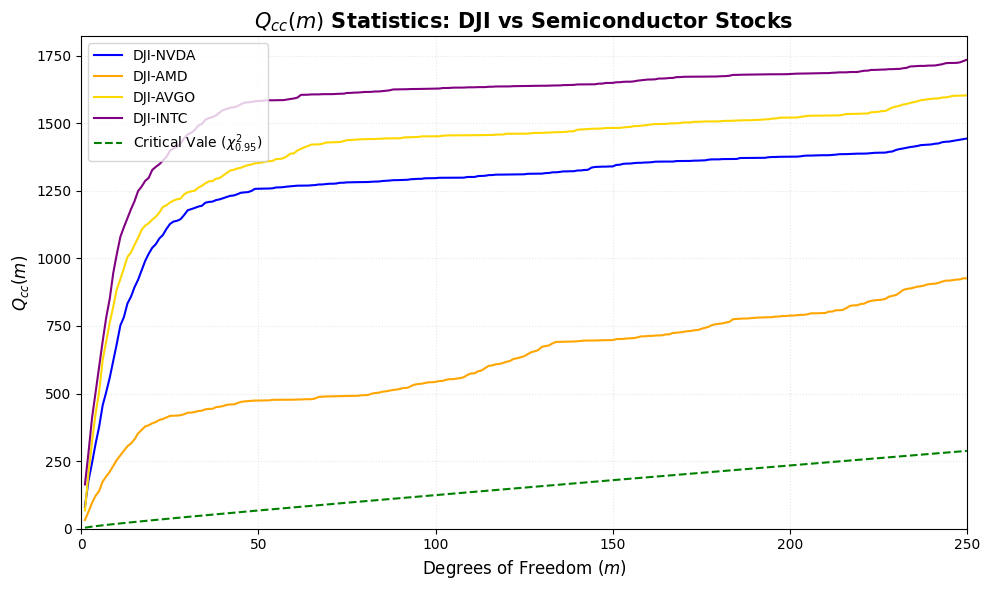

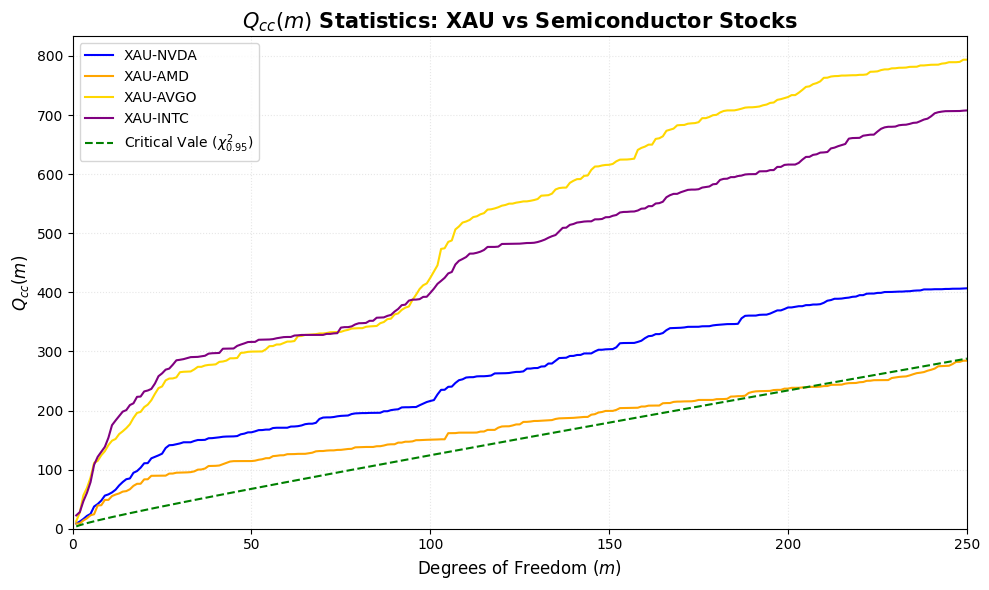

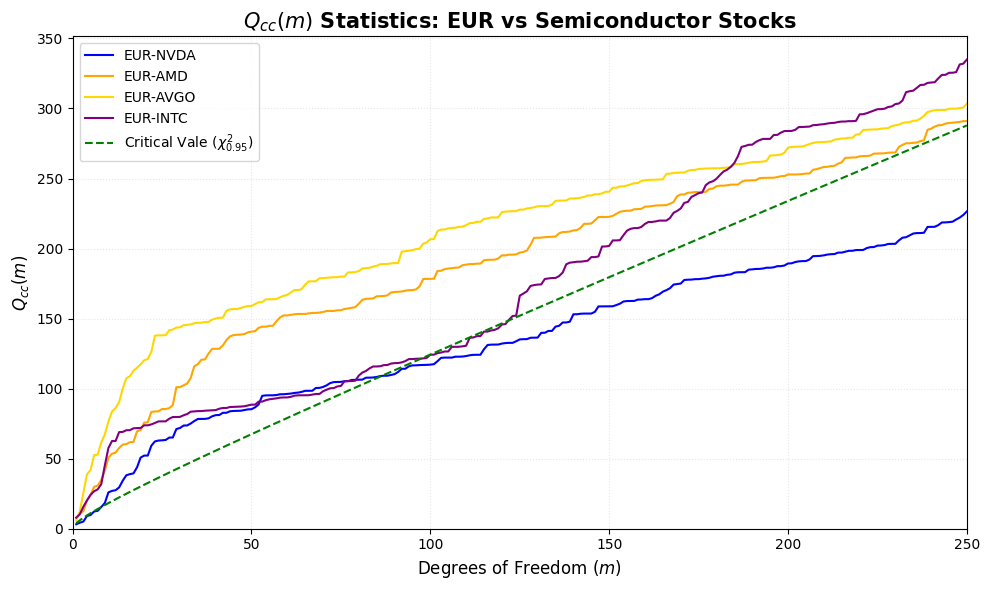

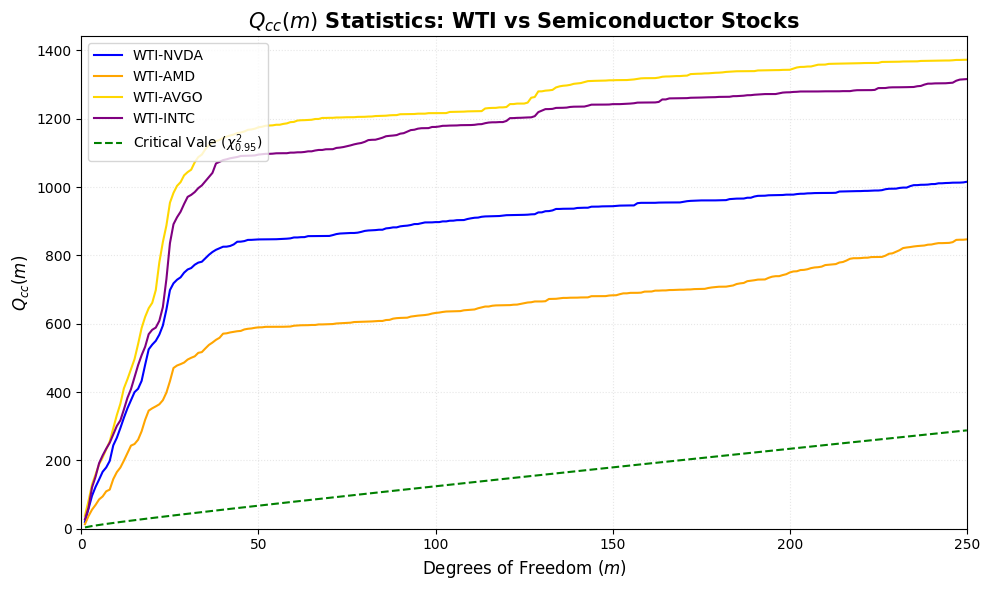

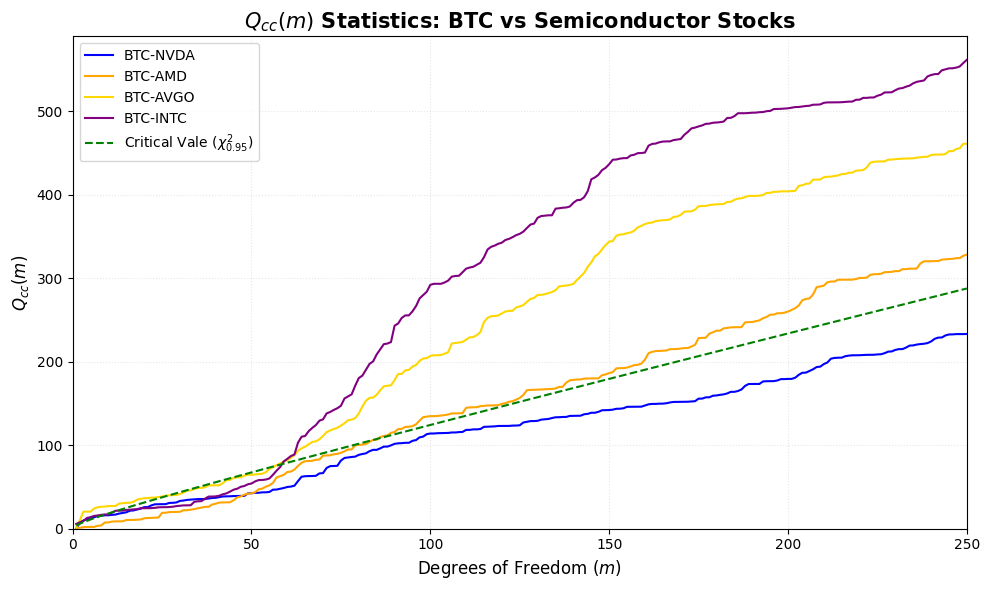

In [13]:
df_price = load_data(file_map)

log_returns = np.log(df_price / df_price.shift(1)).dropna()
abs_log_returns = np.abs(log_returns)

def calculate_qcc(series_x, series_y, max_m = 250):
    common_df = pd.concat([series_x, series_y], axis = 1).dropna()
    x = common_df.iloc[:, 0].values
    y = common_df.iloc[:, 1].values
    N = len(x)

    if N < max_m + 10: return None
    q_stat_list = []
    cumulative_sum = 0
    
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    x_std = np.std(x)
    y_std = np.std(y)
    
    denom = N * x_std * y_std

    for i in range(1, max_m + 1):
        x_lag = x[i:]
        y_lag = y[:-i]
        
        numerator = np.sum((x_lag - x_mean) * (y_lag - y_mean))
        
        rho_i = numerator / denom 
        
        cumulative_sum += (rho_i ** 2) / (N - i)
        
        q_stat = N * (N + 2) * cumulative_sum
        q_stat_list.append(q_stat)

    return q_stat_list

max_m_val = 250
m_range = range(1, max_m_val + 1)

critical_values = [stats.chi2.ppf(0.95, df = m) for m in m_range]

colors = {'NVDA': 'blue', 'AMD': 'orange', 'AVGO': 'gold', 'INTC': 'purple'}

for asset in financial_assets:
    if asset not in abs_log_returns.columns: continue

    plt.figure(figsize = (10, 6))
    asset_data = abs_log_returns[asset]
    plot_exists = False

    for stock in semi_stock:
        if stock not in abs_log_returns.columns: continue

        q_stats = calculate_qcc(asset_data, abs_log_returns[stock], max_m = max_m_val)

        if q_stats is not None:
            plt.plot(m_range, q_stats, label = f'{asset}-{stock}', color = colors[stock], linewidth = 1.5)
            plot_exists = True
    
    if plot_exists:
        plt.plot(m_range, critical_values, label = 'Critical Vale ($\chi^2_{0.95}$)',
                 color = 'green', linestyle = '--', linewidth = 1.5)
        
        plt.title(f'$Q_{{cc}}(m)$ Statistics: {asset} vs Semiconductor Stocks', fontsize = 15, fontweight = 'bold')
        plt.xlabel('Degrees of Freedom ($m$)', fontsize = 12)
        plt.ylabel('$Q_{{cc}}(m)$', fontsize = 12)
        plt.legend(loc = 'upper left', fontsize = 10)
        plt.grid(True, linestyle = ':', alpha = 0.3)
        plt.xlim(0, max_m_val)
        plt.ylim(bottom = 0)

        plt.tight_layout()
        plt.show()


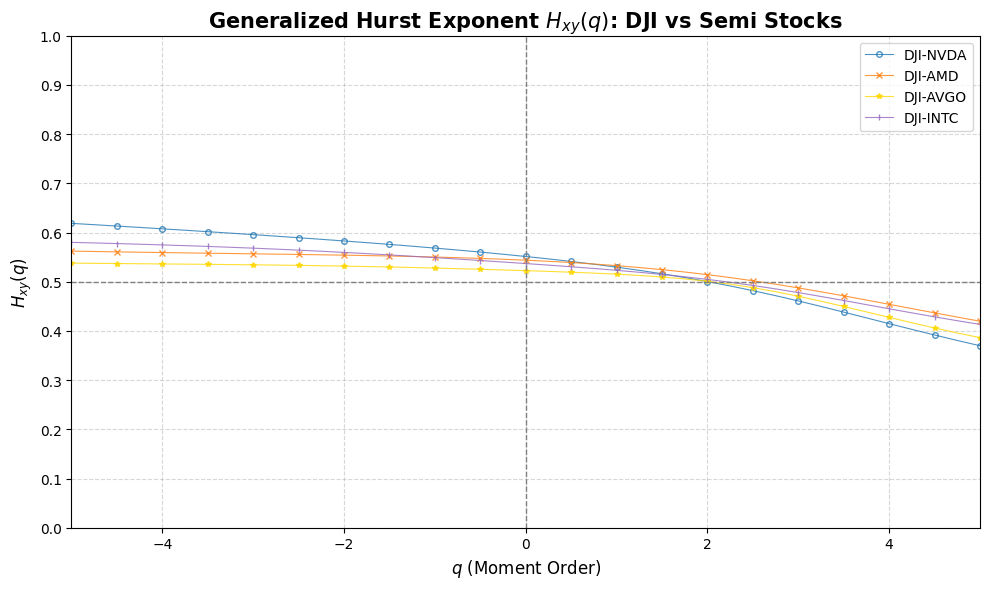

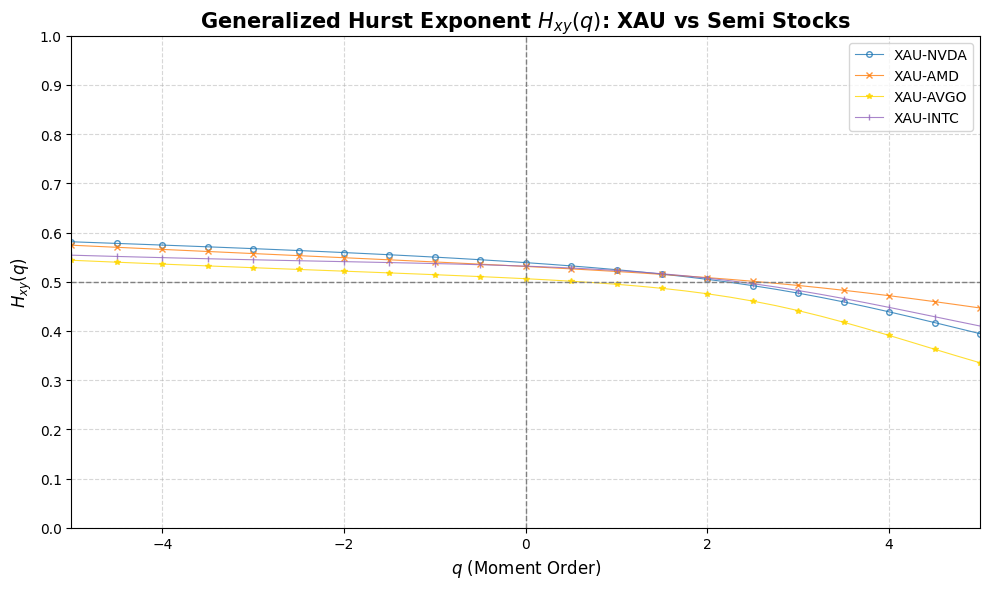

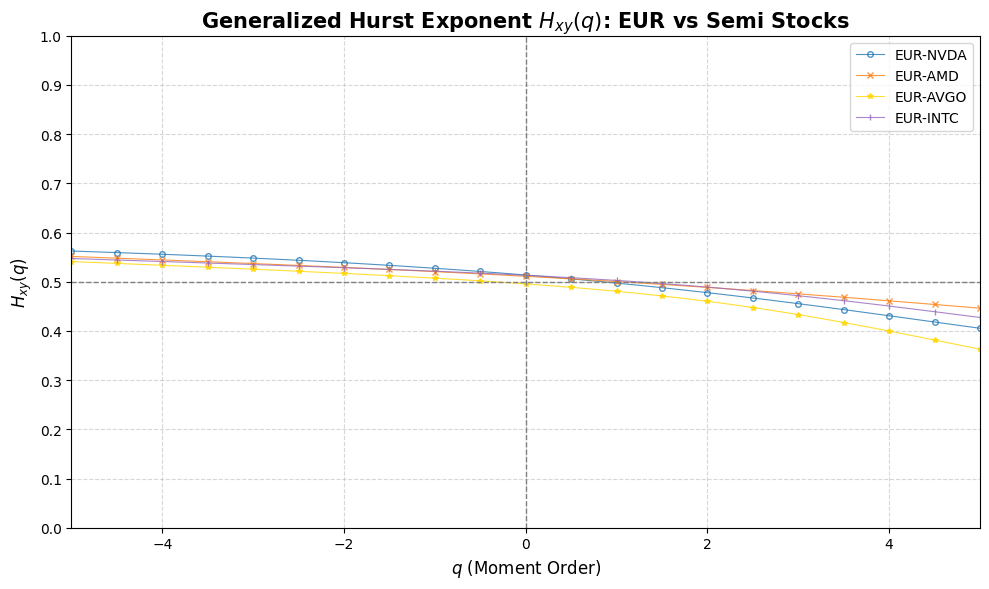

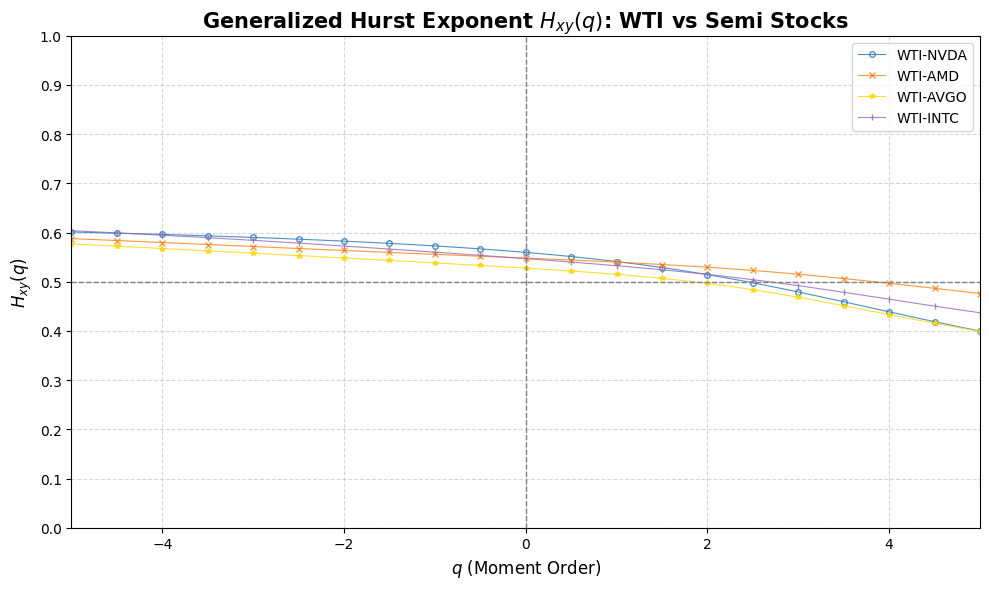

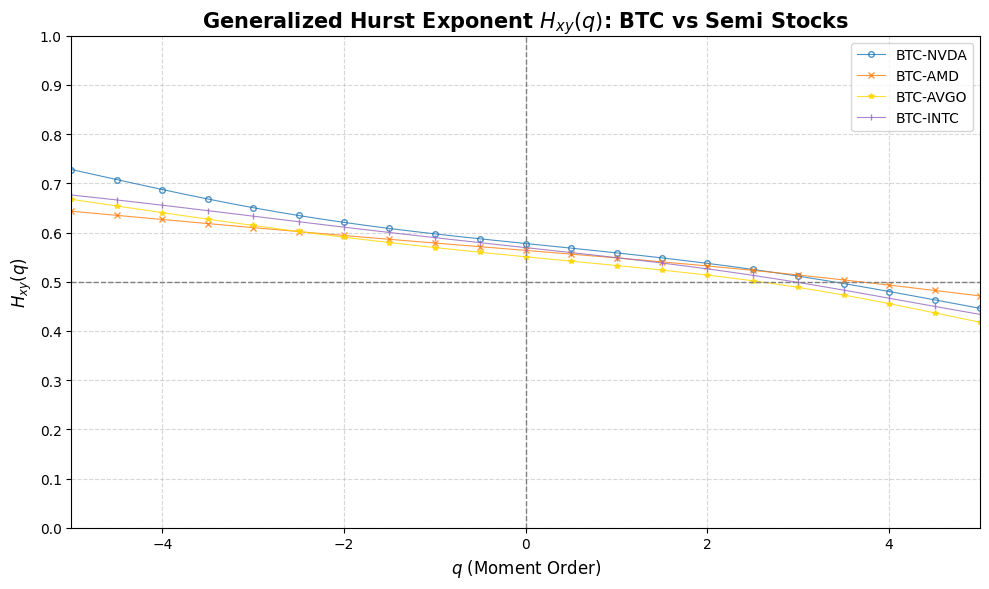

In [14]:
def calculate_hxy(series_x, series_y, q_range, scales, poly_order):
    X = series_x.values
    Y = series_y.values

    X_profile = np.cumsum(X - np.mean(X))
    Y_profile = np.cumsum(Y - np.mean(Y))

    N = len(X)
    valid_scale = [int(s) for s in scales if N // s >= 2]
    if not valid_scale:
        return np.full(len(q_range), np.nan)
        
    F_q_s = np.zeros((len(q_range), len(valid_scale)))


    for i_s, s in enumerate(valid_scale):
        N_s = N // s

        f2_v = np.zeros(2 * N_s)
        x_axis = np.arange(s)

        for v in range(N_s):
            idx_start = v * s
            idx_end = idx_start + s
            x_seg = X_profile[idx_start:idx_end]
            y_seg = Y_profile[idx_start:idx_end]

            p_x = np.polyfit(x_axis, x_seg, poly_order)
            p_y = np.polyfit(x_axis, y_seg, poly_order)

            resid_x = x_seg - np.polyval(p_x, x_axis)
            resid_y = y_seg - np.polyval(p_y, x_axis)

            f2_v[v] = np.mean(np.abs(resid_x) * np.abs(resid_y))

            idx_start_b = N - (v + 1) * s
            idx_end_b = N - v * s
            x_seg_b = X_profile[idx_start_b:idx_end_b]
            y_seg_b = Y_profile[idx_start_b:idx_end_b]

            p_x_b = np.polyfit(x_axis, x_seg_b, poly_order)
            p_y_b = np.polyfit(x_axis, y_seg_b, poly_order)

            resid_x_b = x_seg_b - np.polyval(p_x_b, x_axis)
            resid_y_b = y_seg_b - np.polyval(p_y_b, x_axis)

            f2_v[N_s + v] = np.mean(np.abs(resid_x_b) * np.abs(resid_y_b))

        f2_abs = np.abs(f2_v)
        f2_abs[f2_abs < 1e-10] = 1e-10

        for i_q, q in enumerate(q_range):
            if abs(q) < 1e-5:
                F_val = np.exp(0.5 * np.mean(np.log(f2_abs)))
            else:
                mean_val = np.mean(f2_abs ** (q/2))
                F_val = mean_val ** (1 / q)
            F_q_s[i_q, i_s] = F_val

    h_xy_list = []
    log_s = np.log(valid_scale)

    for i_q in range(len(q_range)):
        log_F = np.log(F_q_s[i_q, :])
        valid_mask = np.isfinite(log_F) & np.isfinite(log_s)
        if np.sum(valid_mask) >= 3:
            slope, _, _, _, _ = linregress(log_s[valid_mask], log_F[valid_mask])
            h_xy_list.append(slope)
        else:
            h_xy_list.append(np.nan)

    return np.array(h_xy_list)

styles = {
    'NVDA': {'marker': 'o', 'fillstyle': 'none', 'color': 'tab:blue', 'label': 'NVDA'}, 
    'AMD':  {'marker': 'x', 'fillstyle': 'full', 'color': 'tab:orange', 'label': 'AMD'}, 
    'AVGO': {'marker': '*', 'fillstyle': 'full', 'color': 'gold', 'label': 'AVGO'}, 
    'INTC': {'marker': '|', 'fillstyle': 'full', 'color': 'tab:purple', 'label': 'INTC'} 
}

q_range = np.linspace(-5, 5, 41)
min_scale = 20
max_scale = 240
scales = np.unique(np.logspace(np.log10(min_scale), np.log10(max_scale), 20).astype(int))
poly_order = 3

for asset in financial_assets:
    if asset not in log_returns.columns: continue

    plt.figure(figsize = (10, 6))
    plot_exists = False

    for stock in semi_stock:
        if stock not in log_returns.columns: continue

        df_pair = log_returns[[asset, stock]].dropna()
        if len(df_pair) < 300:
            continue

        h_vals = calculate_hxy(df_pair[asset], df_pair[stock], q_range, scales, poly_order)

        if not np.all(np.isnan(h_vals)):
            st = styles[stock]
            plt.plot(q_range, h_vals, label = f'{asset}-{stock}', color = st['color'], linewidth = 0.8,
                     marker = st['marker'], markersize = 4, fillstyle = st['fillstyle'],
                     markevery = 2, alpha = 0.8)
            plot_exists = True
        
    if plot_exists:
        plt.title(f"Generalized Hurst Exponent $H_{{xy}}(q)$: {asset} vs Semi Stocks", fontsize = 15, fontweight = 'bold')
        plt.xlabel('$q$ (Moment Order)', fontsize=12)
        plt.ylabel('$H_{{xy}}(q)$', fontsize=12)
        plt.axhline(y=0.5, color='gray', linestyle='--', linewidth = 1)
        plt.axvline(x = 0, color = 'gray', linestyle = '--', linewidth = 1)
        plt.ylim(0, 1.0)
        plt.yticks(np.arange(0, 1.1, 0.1))
        plt.xlim(q_range[0], q_range[-1])
        plt.legend(loc='best')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()
    else:
        plt.close()

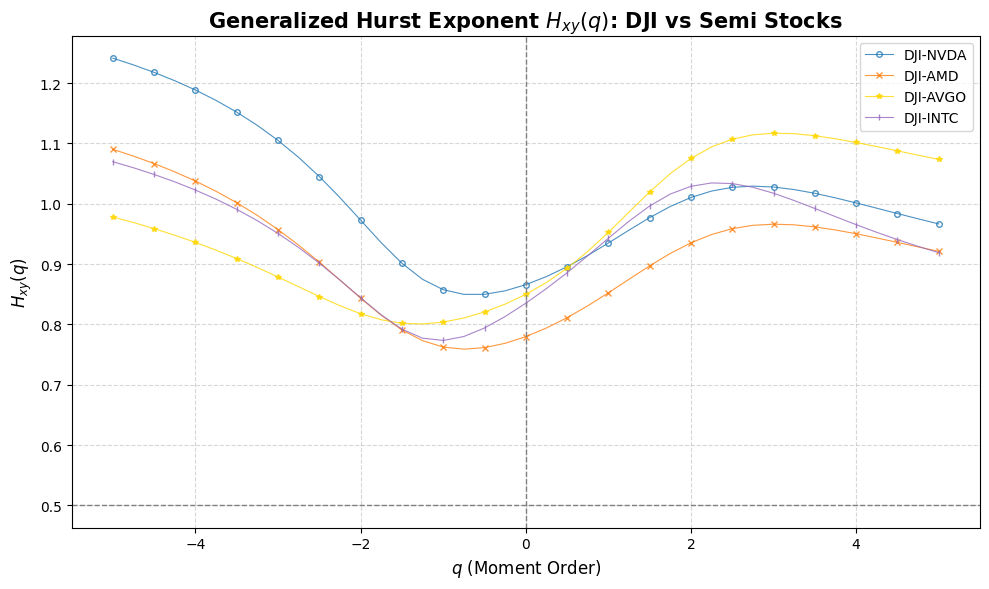

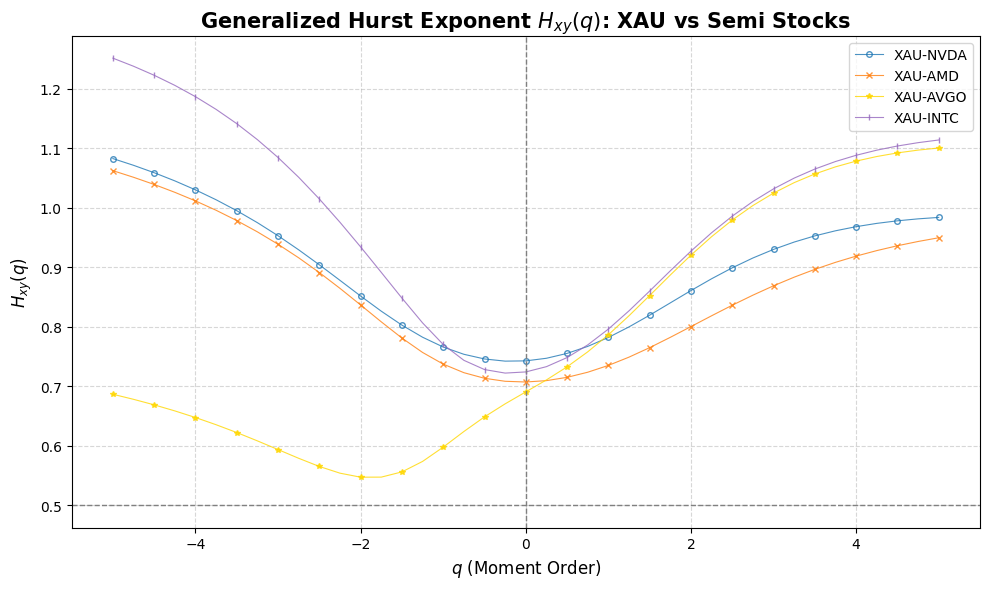

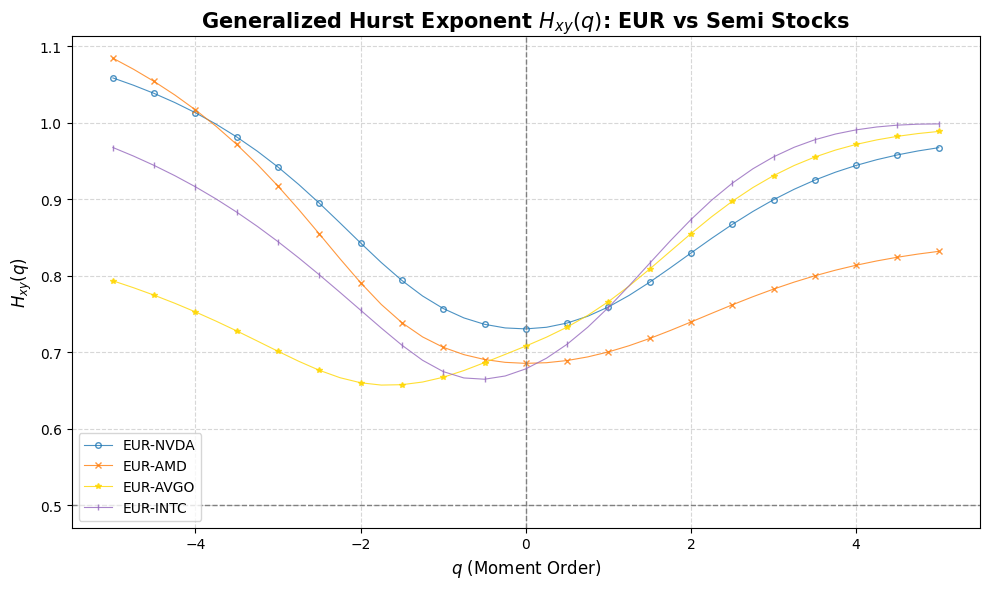

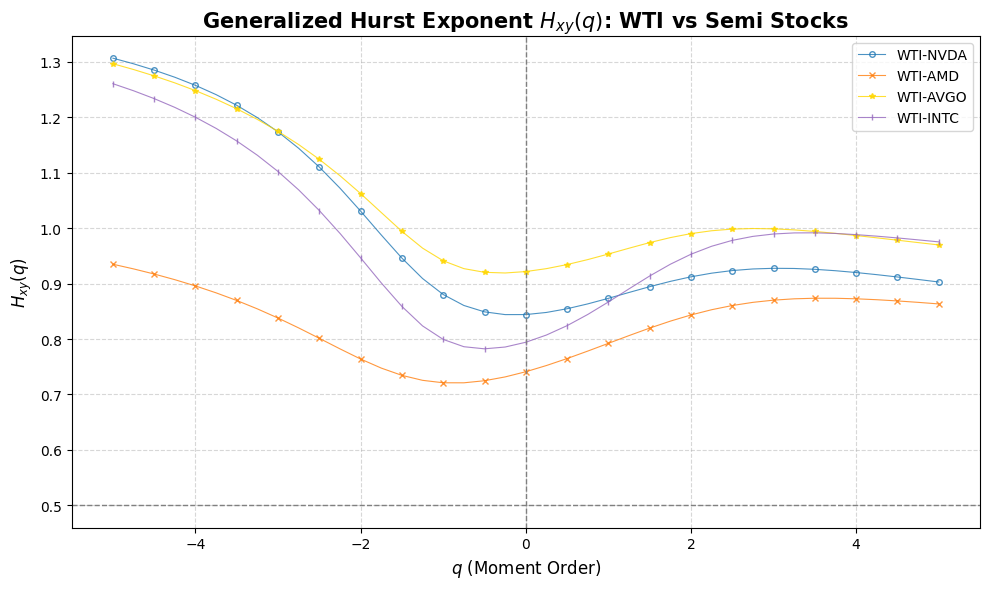

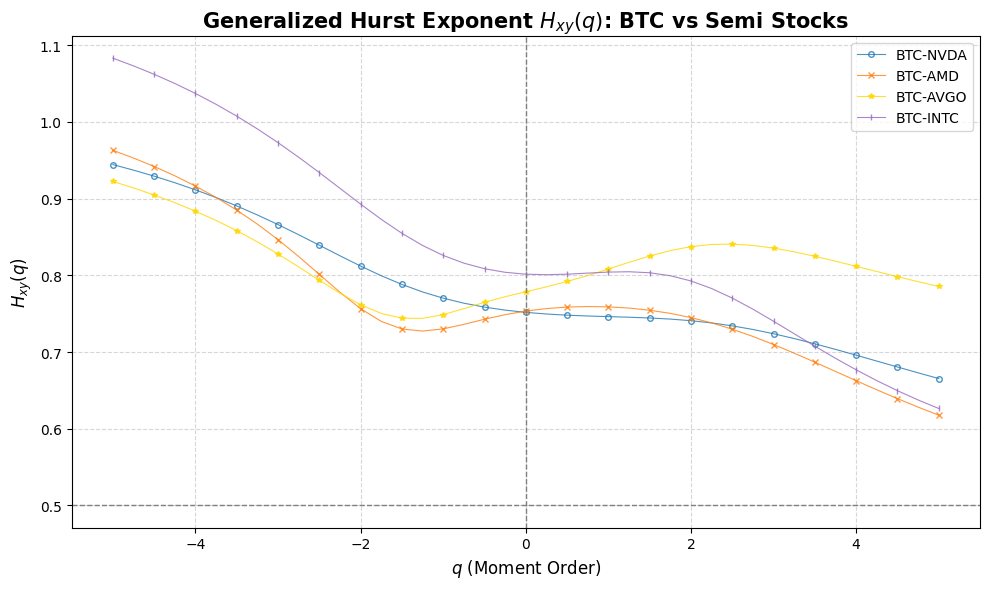

In [15]:
def calculate_hxy(series_x, series_y, q_range, scales, poly_order):
    X = series_x.values
    Y = series_y.values

    X_profile = np.cumsum(X - np.mean(X))
    Y_profile = np.cumsum(Y - np.mean(Y))

    N = len(X)
    F_q_s = np.zeros((len(q_range), len(scales)))


    for i_s, s in enumerate(scales):
        s = int(s)
        N_s = N // s

        f2_v = np.zeros(2 * N_s)
        x_axis = np.arange(s)

        for v in range(N_s):
            idx_start = v * s
            idx_end = idx_start + s
            x_seg = X_profile[idx_start:idx_end]
            y_seg = Y_profile[idx_start:idx_end]

            p_x = np.polyfit(x_axis, x_seg, poly_order)
            p_y = np.polyfit(x_axis, y_seg, poly_order)

            resid_x = x_seg - np.polyval(p_x, x_axis)
            resid_y = y_seg - np.polyval(p_y, x_axis)

            f2_v[v] = np.mean(resid_x * resid_y)

            idx_start_b = N - (v + 1) * s
            idx_end_b = N - v * s
            x_seg_b = X_profile[idx_start_b:idx_end_b]
            y_seg_b = Y_profile[idx_start_b:idx_end_b]

            p_x_b = np.polyfit(x_axis, x_seg_b, poly_order)
            p_y_b = np.polyfit(x_axis, y_seg_b, poly_order)

            resid_x_b = x_seg_b - np.polyval(p_x_b, x_axis)
            resid_y_b = y_seg_b - np.polyval(p_y_b, x_axis)

            f2_v[N_s + v] = np.mean(resid_x_b * resid_y_b)

        f2_abs = np.abs(f2_v)
        f2_abs[f2_abs < 1e-10] = 1e-10

        for i_q, q in enumerate(q_range):
            if abs(q) < 1e-5:
                F_val = np.exp(0.5 * np.mean(np.log(f2_abs)))
            else:
                mean_val = np.mean(f2_abs ** (q/2))
                F_val = mean_val ** (1 / q)
            F_q_s[i_q, i_s] = F_val

    h_xy_list = []
    log_s = np.log(scales)

    for i_q in range(len(q_range)):
        log_F = np.log(F_q_s[i_q, :])
        valid_mask = np.isfinite(log_F) & np.isfinite(log_s)
        if np.sum(valid_mask) >= 3:
            slope, _, _, _, _ = linregress(log_s[valid_mask], log_F[valid_mask])
            h_xy_list.append(slope)
        else:
            h_xy_list.append(np.nan)

    return np.array(h_xy_list)

styles = {
    'NVDA': {'marker': 'o', 'fillstyle': 'none', 'color': 'tab:blue', 'label': 'NVDA'}, 
    'AMD':  {'marker': 'x', 'fillstyle': 'full', 'color': 'tab:orange', 'label': 'AMD'}, 
    'AVGO': {'marker': '*', 'fillstyle': 'full', 'color': 'gold', 'label': 'AVGO'}, 
    'INTC': {'marker': '|', 'fillstyle': 'full', 'color': 'tab:purple', 'label': 'INTC'} 
}

q_range = np.linspace(-5, 5, 41)
min_scale = 20
max_scale = 240
scales = np.unique(np.logspace(np.log10(min_scale), np.log10(max_scale), 15).astype(int))
poly_order = 3

abs_returns = np.abs(log_returns)


for asset in financial_assets:
    if asset not in abs_returns.columns: continue

    plt.figure(figsize = (10, 6))
    plot_exists = False

    for stock in semi_stock:
        if stock not in abs_returns.columns: continue

        df_pair = abs_returns[[asset, stock]].dropna()
        if len(df_pair) < 300:
            continue

        h_vals = calculate_hxy(df_pair[asset], df_pair[stock], q_range, scales, poly_order)

        if not np.all(np.isnan(h_vals)):
            st = styles[stock]
            plt.plot(q_range, h_vals, label = f'{asset}-{stock}', color = st['color'], linewidth = 0.8,
                     marker = st['marker'], markersize = 4, fillstyle = st['fillstyle'],
                     markevery = 2, alpha = 0.8)
            plot_exists = True
        
    if plot_exists:
        plt.title(f"Generalized Hurst Exponent $H_{{xy}}(q)$: {asset} vs Semi Stocks", fontsize = 15, fontweight = 'bold')
        plt.xlabel('$q$ (Moment Order)', fontsize=12)
        plt.ylabel('$H_{{xy}}(q)$', fontsize=12)
        plt.axhline(y=0.5, color='gray', linestyle='--', linewidth = 1)
        plt.axvline(x = 0, color = 'gray', linestyle = '--', linewidth = 1)
        plt.legend(loc='best')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()
    else:
        plt.close()

In [16]:
delta_h = h_vals[0] - h_vals[-1]
table_3 = pd.DataFrame(index = semi_stock, columns = financial_assets)

for asset in financial_assets:
    if asset not in abs_returns.columns: continue

    for stock in semi_stock:
        if stock not in abs_returns.columns: continue

        df_pair = abs_returns[[asset, stock]].dropna()
        if len(df_pair) < 300:
            continue

        h_vals = calculate_hxy(df_pair[asset], df_pair[stock], q_range, scales, poly_order)

        if not np.all(np.isnan(h_vals)):
            delta_h = h_vals[0] - h_vals[-1]
            table_3.loc[stock, asset] = delta_h


pd.options.display.float_format = '{:.4f}'.format
print(table_3)

         DJI     XAU     EUR    WTI    BTC
NVDA  0.2748  0.0988  0.0912 0.4038 0.2790
AMD   0.1691  0.1127  0.2526 0.0716 0.3454
AVGO -0.0953 -0.4136 -0.1953 0.3269 0.1370
INTC  0.1508  0.1375 -0.0309 0.2853 0.4569


>>> Calculating Delta H (H_min - H_max)...

=== Delta H Table (Multifractality Degree) ===


,DJI,XAU,EUR,WTI,BTC
NVDA,0.2488,0.1868,0.1570,0.2014,0.2821
AMD,0.1426,0.1276,0.1052,0.1116,0.1721
AVGO,0.1515,0.2084,0.1781,0.1776,0.2497
INTC,0.1668,0.1440,0.1199,0.1668,0.2426


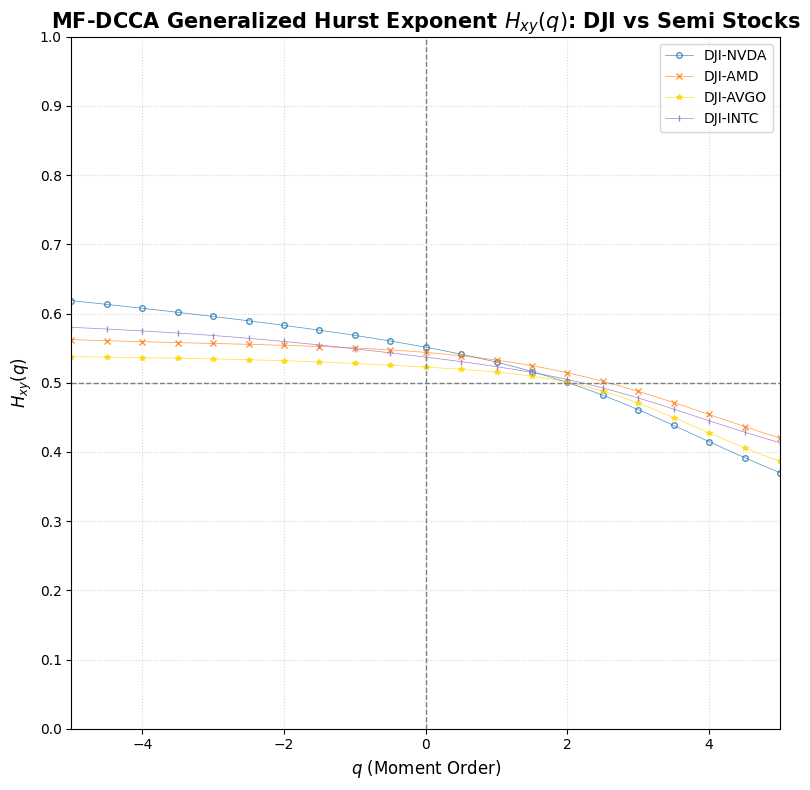

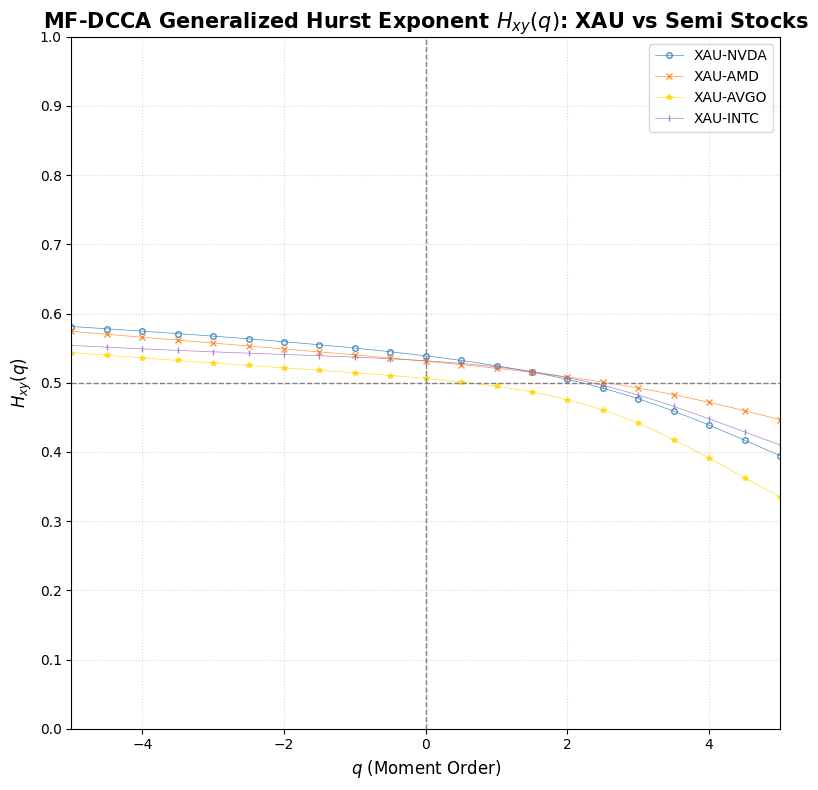

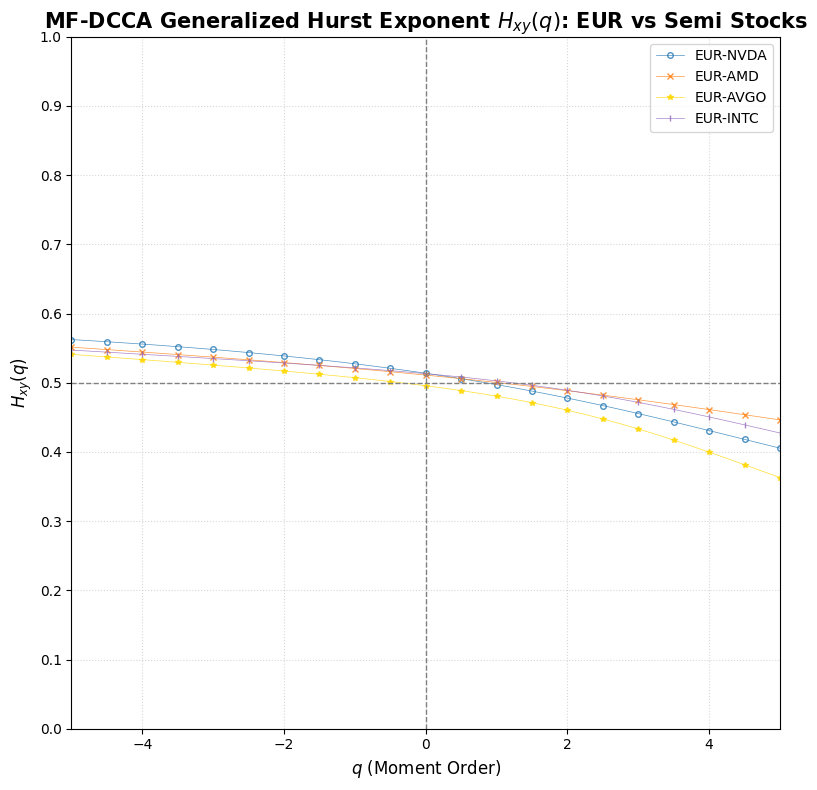

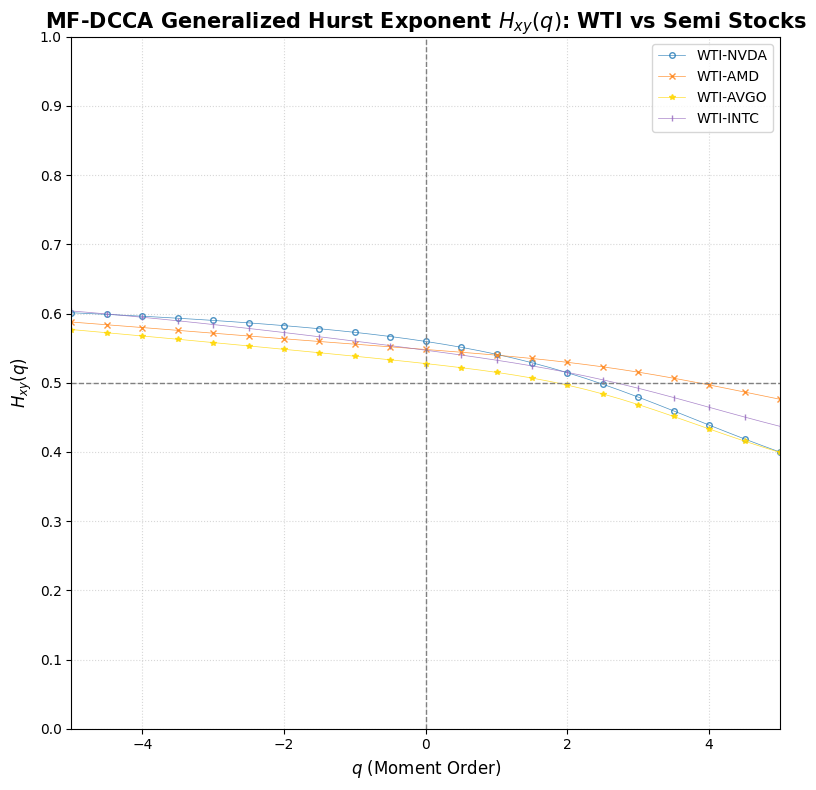

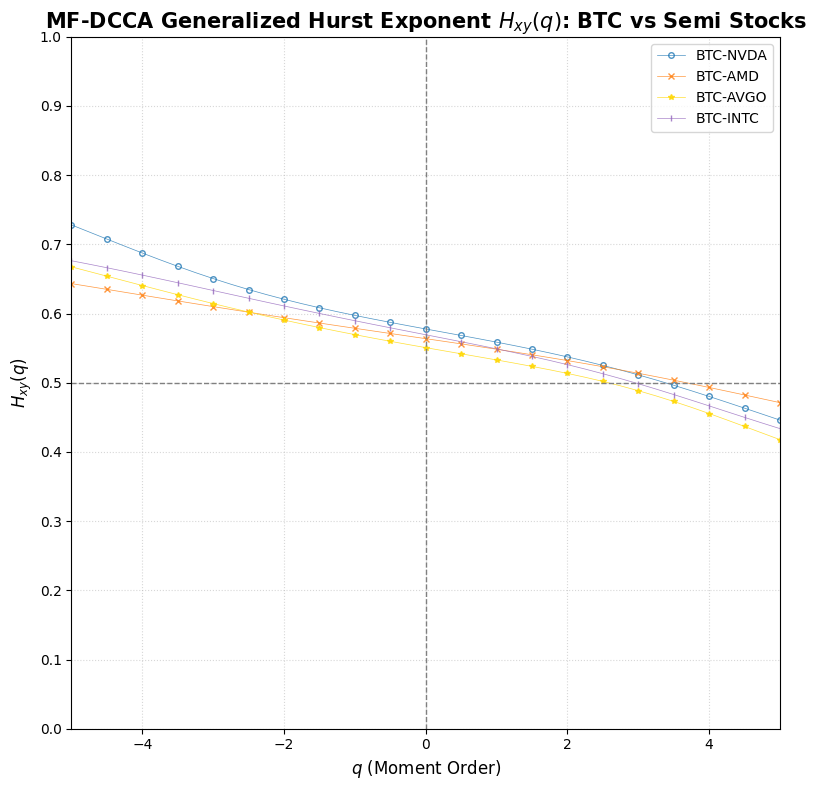

In [17]:
def mfdcca(x, y, q_range, scales, poly_order):

    X = np.cumsum(x - np.mean(x))
    Y = np.cumsum(y - np.mean(y))

    N = len(X)
    valid_scales = [s for s in scales if N // s >= 2]
    F_q_s = np.zeros((len(q_range), len(valid_scales)))
    eps = 1e-10

    for i_s, s in enumerate(valid_scales):
        N_s = N // s
        F2 = []


        for v in range(N_s):
            x_seg = X[v * s:(v+1)*s]
            y_seg = Y[v * s:(v+1)*s]
            t = np.arange(s)

            p_x = np.polyfit(t, x_seg, poly_order)
            p_y = np.polyfit(t, y_seg, poly_order)

            resid_x = x_seg - np.polyval(p_x, t)
            resid_y = y_seg - np.polyval(p_y, t)

            F2.append(np.mean(np.abs(resid_x) * np.abs(resid_y)))
        
        for v in range(N_s):
            x_seg = X[N-(v+1)*s:N-v*s]
            y_seg = Y[N-(v+1)*s:N-v*s]
            t = np.arange(s)
            
            p_x = np.polyfit(t, x_seg, poly_order)
            p_y = np.polyfit(t, y_seg, poly_order)
            
            resid_x = x_seg - np.polyval(p_x, t)
            resid_y = y_seg - np.polyval(p_y, t)
            
            F2.append(np.mean(np.abs(resid_x) * np.abs(resid_y)))

        F2 = np.array(F2) + eps

        for i_q, q in enumerate(q_range):
            if q == 0:
                F_q_s[i_q, i_s] = np.exp(0.5 * np.mean(np.log(F2)))
            else:
                F_q_s[i_q, i_s] = (np.mean(F2 ** (q/2)) ** (1/q))
    
    return np.array(valid_scales), F_q_s

def compute_cross_spectrum(F_q_s, scales, q_range):
    log_s = np.log(scales)
    Hxy = np.array([np.polyfit(log_s, np.log(F_q_s[i_q, :]), 1)[0] for i_q in range(len(q_range))])
    tau_xy = q_range * Hxy - 1
    alpha = np.gradient(tau_xy, q_range)
    f_alpha = q_range * alpha - tau_xy
    return Hxy, tau_xy, alpha, f_alpha

q_range = np.linspace(-5, 5, 41) 

min_scale = 20
max_scale = 240
scales = np.unique(np.logspace(np.log10(min_scale), np.log10(max_scale), 20).astype(int))
poly_order = 3

semi_stock = ['NVDA', 'AMD', 'AVGO', 'INTC']
financial_assets = ['DJI', 'XAU', 'EUR', 'WTI', 'BTC']


delta_h_table = pd.DataFrame(index=semi_stock, columns=financial_assets)


print(">>> Calculating Delta H (H_min - H_max)...")



for asset in financial_assets:
    if asset not in log_returns.columns: continue
        
    for stock in semi_stock:
        if stock not in log_returns.columns: continue
        
        # 데이터 쌍 추출
        df_pair = log_returns[[asset, stock]].dropna()
        
        # 데이터가 너무 적으면 건너뜀
        if len(df_pair) < 300:
            print(f"Skipping {asset}-{stock}: Not enough data")
            delta_h_table.loc[stock, asset] = np.nan
            continue

        try:
            # 1. MF-DCCA 계산
            valid_scales_out, F_q_s = mfdcca(
                df_pair[stock], df_pair[asset], 
                q_range, scales, poly_order
            )
            
            # 2. Hxy 스펙트럼 추출
            Hxy, _, _, _ = compute_cross_spectrum(F_q_s, valid_scales_out, q_range)
            
            # 3. Delta H 계산
            # q_range[0]은 -5 (작은 변동), q_range[-1]은 +5 (큰 변동)
            # Delta H = H(q_min) - H(q_max)
            delta_val = Hxy[0] - Hxy[-1]
            
            delta_h_table.loc[stock, asset] = delta_val
            
        except Exception as e:
            print(f"Error calculating {asset}-{stock}: {e}")
            delta_h_table.loc[stock, asset] = np.nan

# --- 4. 결과 출력 ---
print("\n=== Delta H Table (Multifractality Degree) ===")
# 보기 좋게 소수점 4자리 포맷팅
pd.options.display.float_format = '{:.4f}'.format

# 컬러 입혀서 출력 (높은 값 강조)
display(delta_h_table.style.background_gradient(cmap='Reds', axis=None).format("{:.4f}"))

for assets in financial_assets:
    if assets not in log_returns.columns: continue
    
    plt.figure(figsize = (8, 8))
    plt_exists = False
    
    for stock in semi_stock:
        if stock not in log_returns.columns: continue
        
        df_pair = log_returns[[assets, stock]].dropna()
        
        if len(df_pair) < 300: continue
        
        try:
            valid_scales_out, F_q_s = mfdcca(
                df_pair[stock], df_pair[assets],
                q_range, scales, poly_order
            )
            
            Hxy, _, _, _ = compute_cross_spectrum(F_q_s, valid_scales_out, q_range)
            st = styles[stock]
            plt.plot(q_range, Hxy, label = f'{assets}-{stock}', color = st['color'],
                     linewidth = 0.5, marker = st['marker'], markersize = 4, fillstyle = st['fillstyle'],
                     markevery = 2, alpha = 0.8)
            
            plot_exists = True
            
        except Exception as e:
            print(f"Error: {asset}-{stock} - {e}")
            
    if plot_exists:
        plt.title(f"MF-DCCA Generalized Hurst Exponent $H_{{xy}}(q)$: {assets} vs Semi Stocks", fontsize = 15, fontweight = 'bold')
        plt.xlabel('$q$ (Moment Order)', fontsize=12)
        plt.ylabel('$H_{{xy}}(q)$', fontsize=12)
        plt.axhline(y=0.5, color='gray', linestyle='--', linewidth = 1)
        plt.axvline(x = 0, color = 'gray', linestyle = '--', linewidth = 1)
        plt.xlim(q_range[0], q_range[-1])
        plt.ylim(0, 1.0)
        plt.yticks(np.arange(0, 1.1, 0.1))
        plt.legend(loc='best')
        plt.grid(True, linestyle=':', alpha=0.5)
        plt.tight_layout()
        plt.show()

Generating Multifractal Spectrum for DJI pairs...


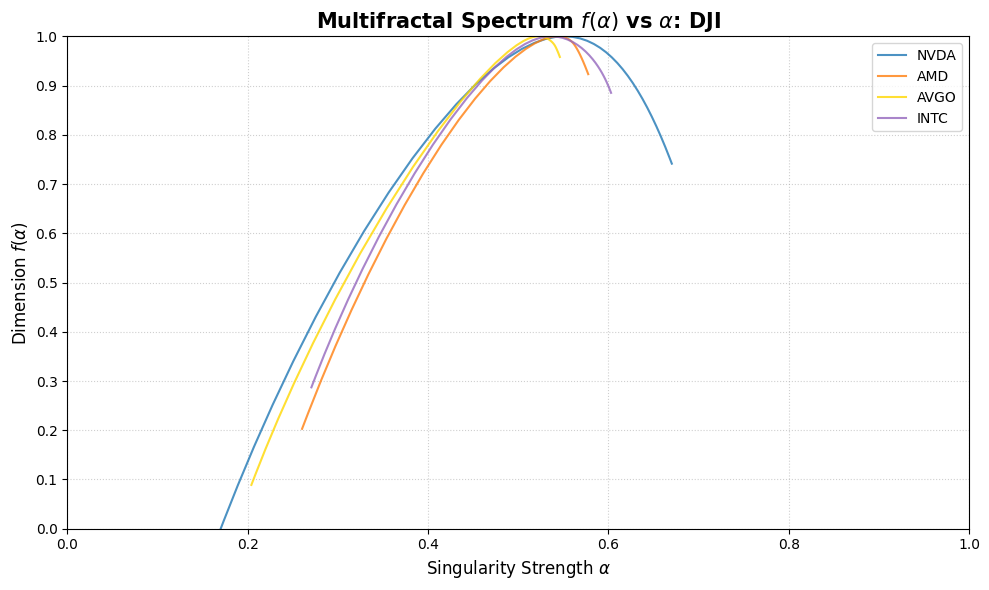

Generating Multifractal Spectrum for XAU pairs...


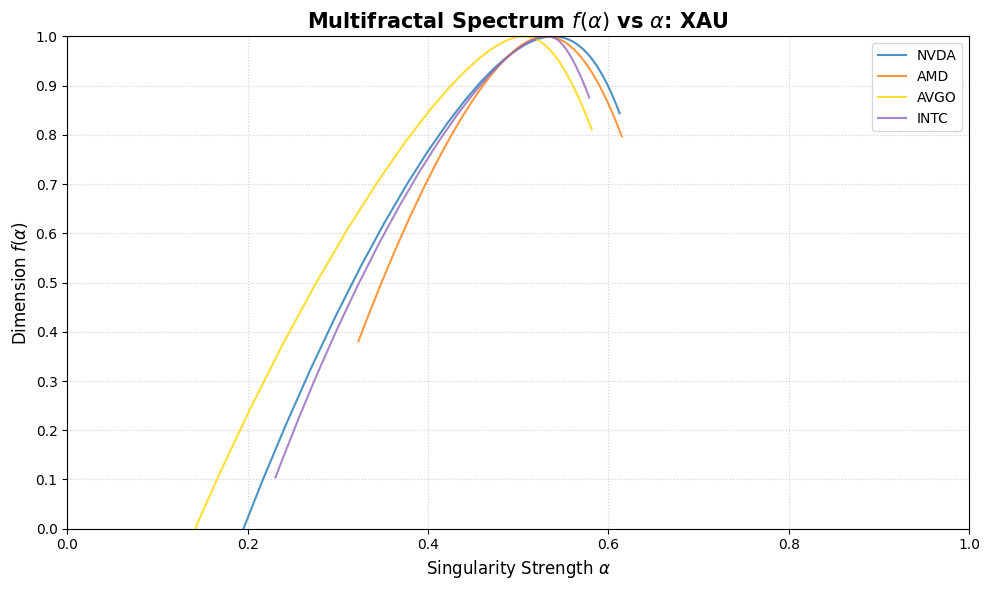

Generating Multifractal Spectrum for EUR pairs...


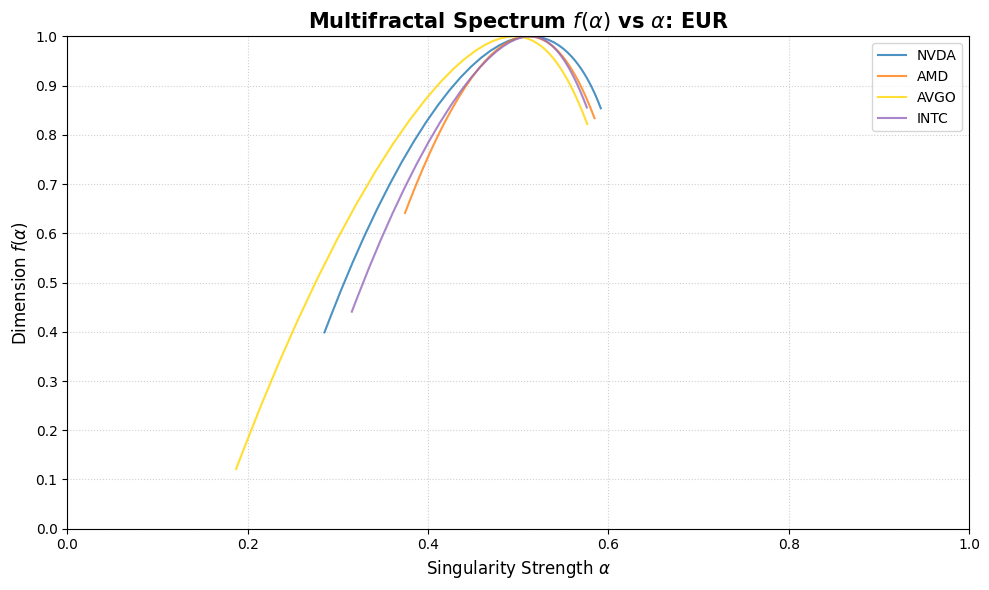

Generating Multifractal Spectrum for WTI pairs...


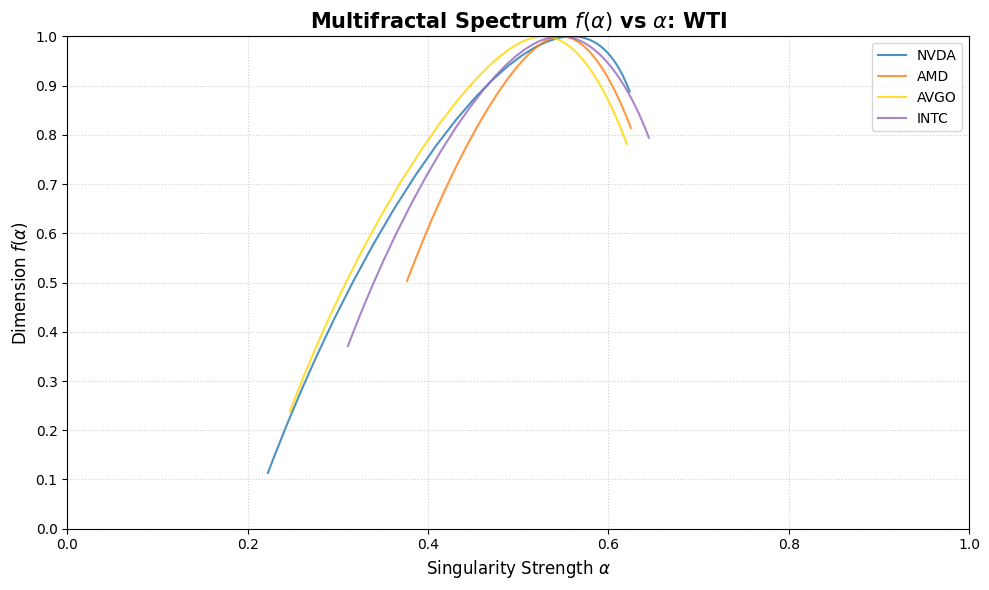

Generating Multifractal Spectrum for BTC pairs...


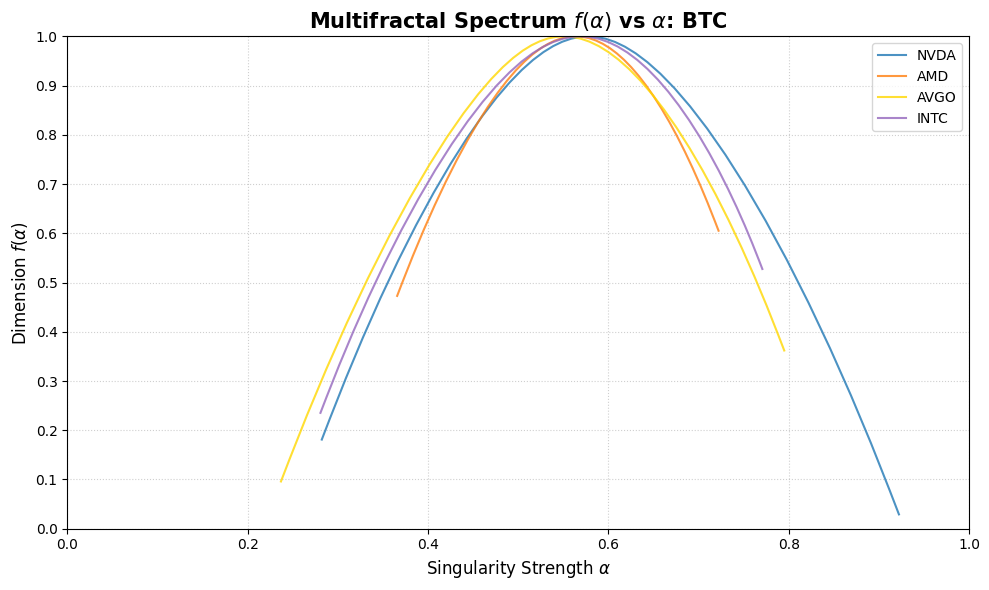


=== Multifractal Parameters (Delta Alpha & Alpha 0) ===


In [18]:
columns = pd.MultiIndex.from_product(
    [financial_assets, ['Δα (Width)', 'α0 (Peak)']],
    names=['Asset', 'Metric']
)
mf_table = pd.DataFrame(index=semi_stock, columns=columns)

# --- 2. 분석 및 시각화 루프 ---
# log_returns를 사용 (방향성 포함 분석)
target_data = log_returns 

for asset in financial_assets:
    if asset not in target_data.columns: continue
    
    plt.figure(figsize=(10, 6))
    plot_exists = False
    print(f"Generating Multifractal Spectrum for {asset} pairs...")

    for stock in semi_stock:
        if stock not in target_data.columns: continue
        
        df_pair = target_data[[asset, stock]].dropna()
        if len(df_pair) < 300: continue

        try:
            # 1. MF-DCCA 계산
            valid_scales_out, F_q_s = mfdcca(
                df_pair[stock], df_pair[asset], 
                q_range, scales, poly_order
            )
            
            # 2. 스펙트럼(alpha, f_alpha) 추출
            # 이미 가지고 있는 compute_cross_spectrum 함수 사용
            _, _, alpha, f_alpha = compute_cross_spectrum(F_q_s, valid_scales_out, q_range)
            
            # 3. 지표 계산
            # Delta Alpha = max(alpha) - min(alpha) (스펙트럼의 폭)
            delta_alpha = np.max(alpha) - np.min(alpha)
            
            # Alpha 0 = q가 0에 가장 가까울 때의 alpha 값 (스펙트럼의 꼭대기 위치)
            # q_range에서 0에 가장 가까운 인덱스 찾기
            idx_0 = np.argmin(np.abs(q_range))
            alpha_0 = alpha[idx_0]
            
            # 4. 테이블에 저장
            mf_table.loc[stock, (asset, 'Δα (Width)')] = delta_alpha
            mf_table.loc[stock, (asset, 'α0 (Peak)')] = alpha_0
            
            # 5. 그래프 그리기 (f(alpha) vs alpha)
            st = styles[stock]
            plt.plot(alpha, f_alpha, label=f'{stock}', 
                     color=st['color'], alpha=0.8)
            
            plot_exists = True

        except Exception as e:
            print(f"Error {asset}-{stock}: {e}")

    if plot_exists:
        plt.title(f'Multifractal Spectrum $f(\\alpha)$ vs $\\alpha$: {asset}', fontsize=15, fontweight='bold')
        plt.xlabel('Singularity Strength $\\alpha$', fontsize=12)
        plt.ylabel('Dimension $f(\\alpha)$', fontsize=12)
        plt.legend(loc='best', fontsize=10)
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.xlim(0, 1)
        plt.xticks(np.arange(0, 1.1, 0.2))
        plt.ylim(0, 1)
        plt.yticks(np.arange(0, 1.1, 0.1))
        
        plt.tight_layout()
        plt.show()
    else:
        plt.close()

# --- 3. 결과 테이블 출력 ---
print("\n=== Multifractal Parameters (Delta Alpha & Alpha 0) ===")
pd.options.display.float_format = '{:.4f}'.format
# NaN 값은 '-'로 표시하거나 비워둠
display(mf_table.style.background_gradient(cmap='Blues', subset=pd.IndexSlice[:, (slice(None), 'Δα (Width)')])\
        .background_gradient(cmap='Oranges', subset=pd.IndexSlice[:, (slice(None), 'α0 (Peak)')])\
        .format("{:.4f}"))

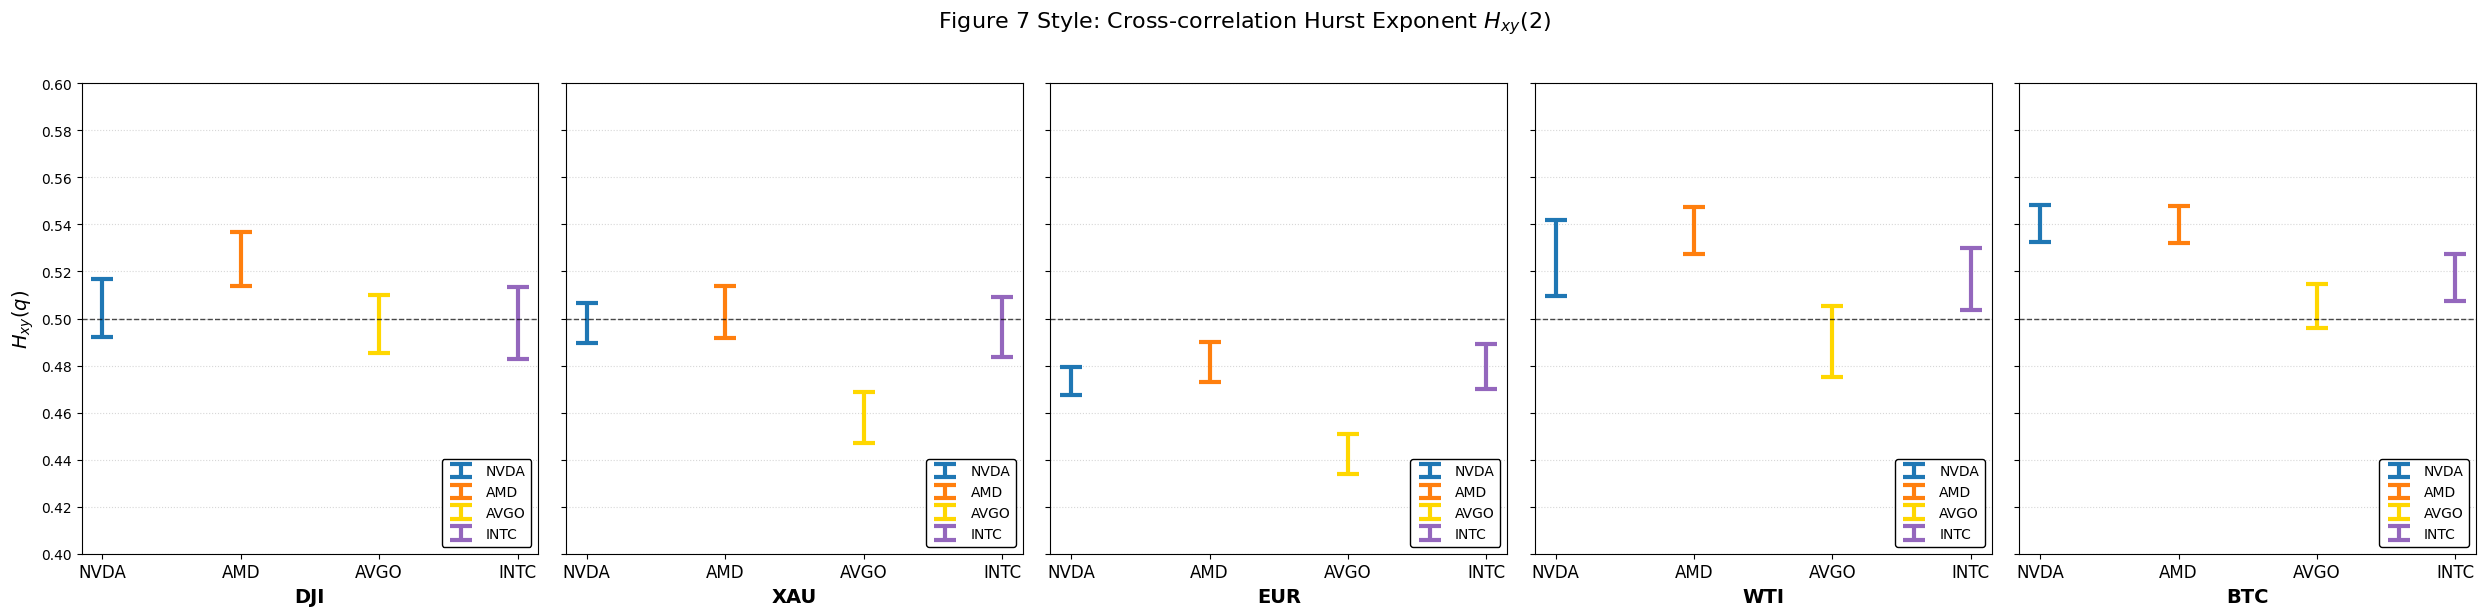

In [19]:
MIN_SCALE = 30
MAX_SCALE = 300

q_target = np.array([2])

hurst_results = []

for asset in financial_assets:
    for stock in semi_stock:
        if stock not in log_returns.columns or asset not in log_returns.columns:
            continue
        df_pair = log_returns[[stock, asset]].dropna()
        
        if len(df_pair) < 500: continue
        
        scales_opt = np.unique(np.logspace(np.log10(MIN_SCALE), np.log10(MAX_SCALE), 20).astype(int))
        
        valid_scales, F_q_s = mfdcca(
            df_pair[stock], df_pair[asset],
            q_target, scales_opt, poly_order
        )
        
        log_s = np.log(valid_scales)
        log_F = np.log(F_q_s[0, :])
        
        slope, intercept, r_value, p_value, std_err = linregress(log_s, log_F)
        
        h_xy_2 = slope
        
        ci_margin = 1.96 * std_err
        ci_lower = h_xy_2 - ci_margin
        ci_upper = h_xy_2 + ci_margin
        
        hurst_results.append({
            'Financial_Asset': asset,
            'Semi_Stock': stock,
            'H_xy(2)': h_xy_2,
            'CI_Lower': ci_lower,
            'CI_Upper': ci_upper,
            'Error_Margin': ci_margin,
            'R_squared': r_value ** 2
        })
        
df_hurst = pd.DataFrame(hurst_results)

assets_found = df_hurst['Financial_Asset'].unique()
n_assets = len(assets_found)

fig, axes = plt.subplots(1, n_assets, figsize = (5 * n_assets, 6), sharey = True)
if n_assets == 1: axes = [axes]


for i, asset in enumerate(assets_found):
    ax = axes[i]
    subset = df_hurst[df_hurst['Financial_Asset'] == asset]
    
    # X축 위치 설정
    x_pos = np.arange(len(subset))
    stocks = subset['Semi_Stock'].values
    
    # 각 주식별로 에러바 그리기 (반복문으로 색상 개별 적용)
    for j, stock in enumerate(stocks):
        row = subset[subset['Semi_Stock'] == stock].iloc[0]
        st = styles[stock]
        
        # === 핵심: Errorbar 그리기 ===
        ax.errorbar(
            x=j, 
            y=row['H_xy(2)'], 
            yerr=row['Error_Margin'], 
            fmt='none',       # 점들끼리 선으로 잇지 않음
            ecolor=st['color'],     # 수직선 색상
            elinewidth=3,     # 수직선 두께 (두껍게)
            capsize=8,        # 위아래 캡(모자) 크기
            capthick=3,       # 캡의 두께
            marker='_',       # 중앙값 표시 (가로선 모양)
            markersize=15,    # 중앙값 마커 크기
            markeredgecolor=color,
            markeredgewidth=3,
            label=stock       # 범례용 라벨
        )

    # --- 데코레이션 ---
    # Random Walk 기준선 (0.5)
    ax.axhline(y=0.5, color='black', linestyle='--', linewidth=1, alpha=0.7)
    
    # X축 설정
    ax.set_xticks(x_pos)
    ax.set_xticklabels(stocks, fontsize=12)
    ax.set_xlabel(asset, fontsize=14, fontweight='bold') # X축 라벨에 자산 이름(BTC 등) 표시
    
    # Y축 설정 (보여주신 이미지처럼 0.5를 중심으로)
    if i == 0:
        ax.set_ylabel('$H_{xy}(q)$', fontsize=14)
    
    # Y축 범위 및 눈금 (AttributeError 방지 위해 set_yticks 사용)
    ax.set_ylim(0.4, 0.6)
    ax.set_yticks(np.arange(0.4, 0.61, 0.02))
    
    # 격자
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    
    # 범례 표시 (중복 제거)
    # 한 axes에 대해 주식별로 label을 달았으므로 그냥 legend() 호출하면 됨
    handles, labels = ax.get_legend_handles_labels()
    # 범례가 주식 순서대로 나오게 정렬하거나 그대로 출력
    ax.legend(loc='lower right', fontsize=10, framealpha=1, edgecolor='black')

plt.suptitle(f'Figure 7 Style: Cross-correlation Hurst Exponent $H_{{xy}}(2)$', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

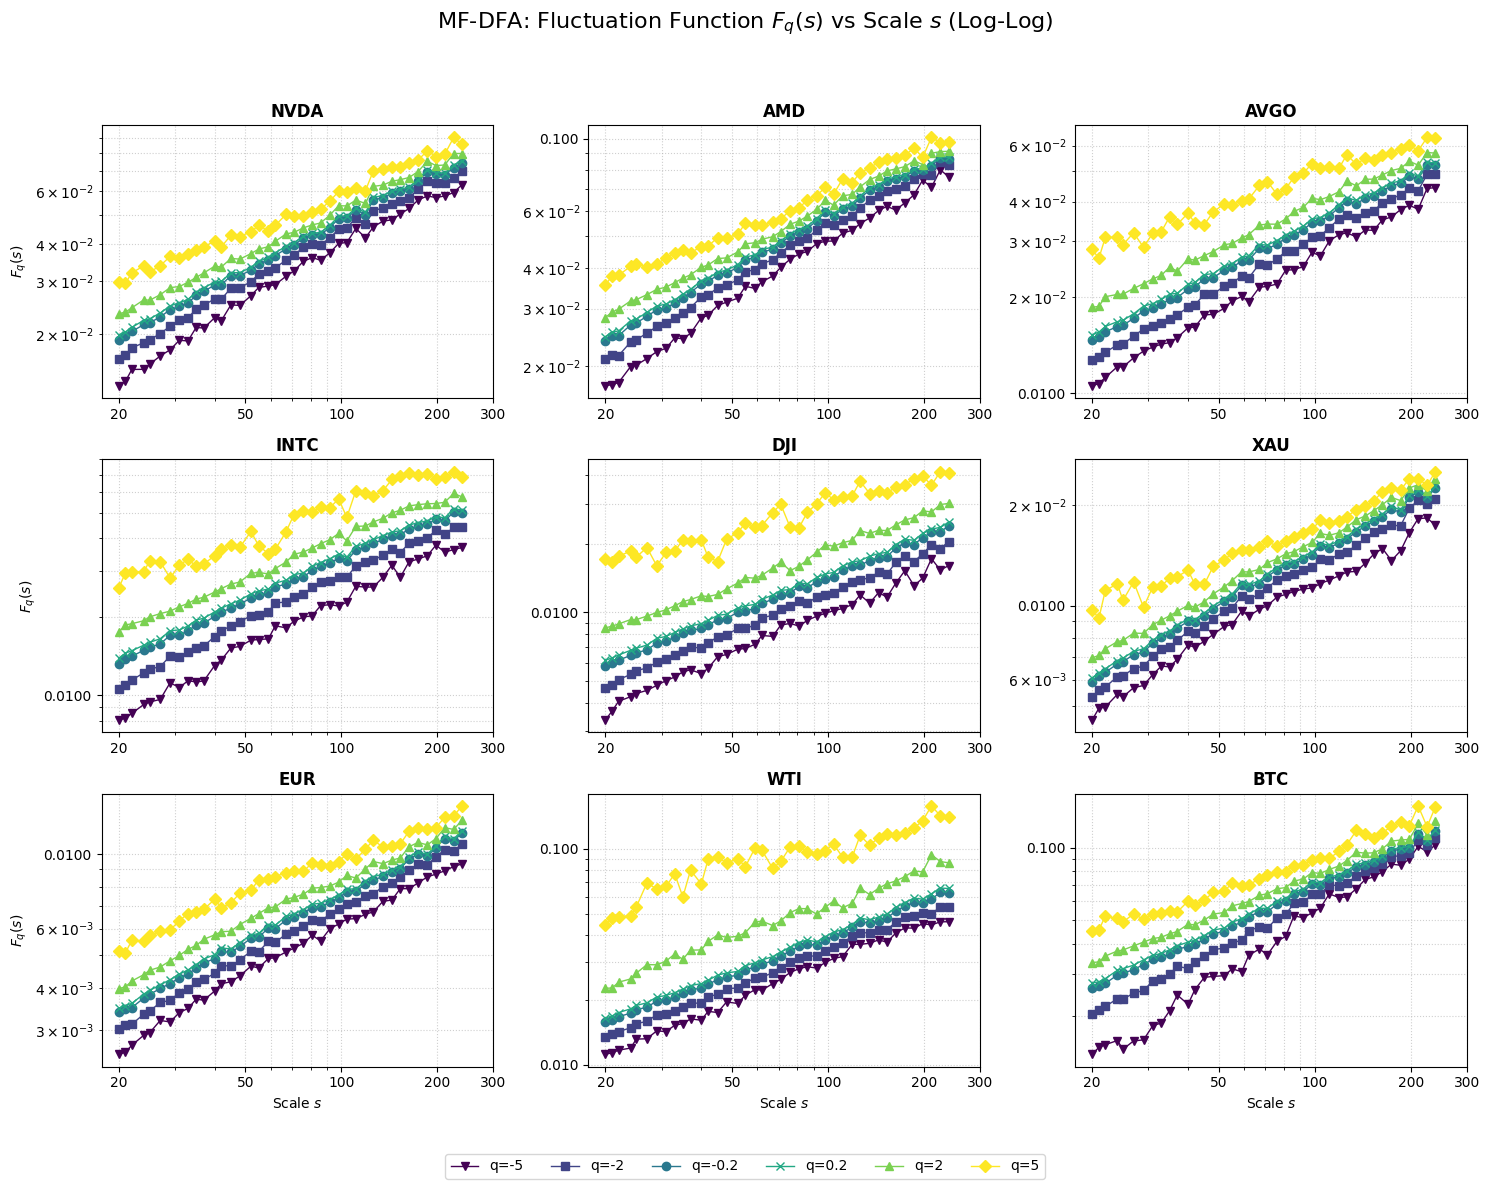

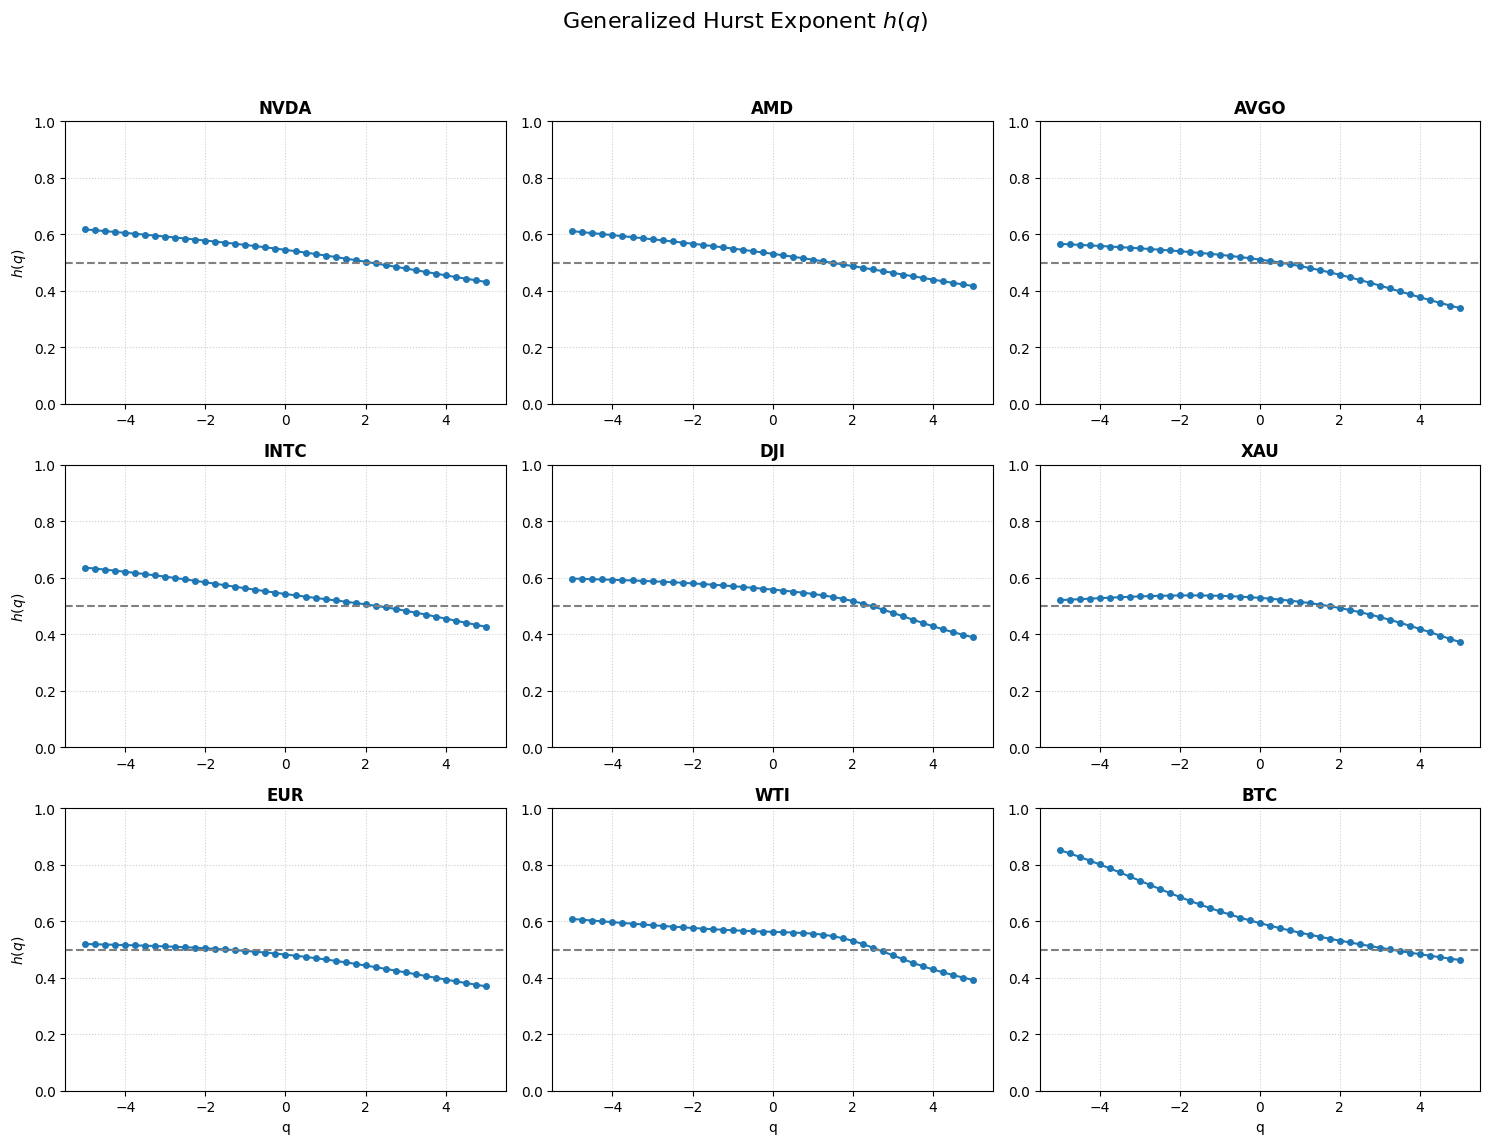

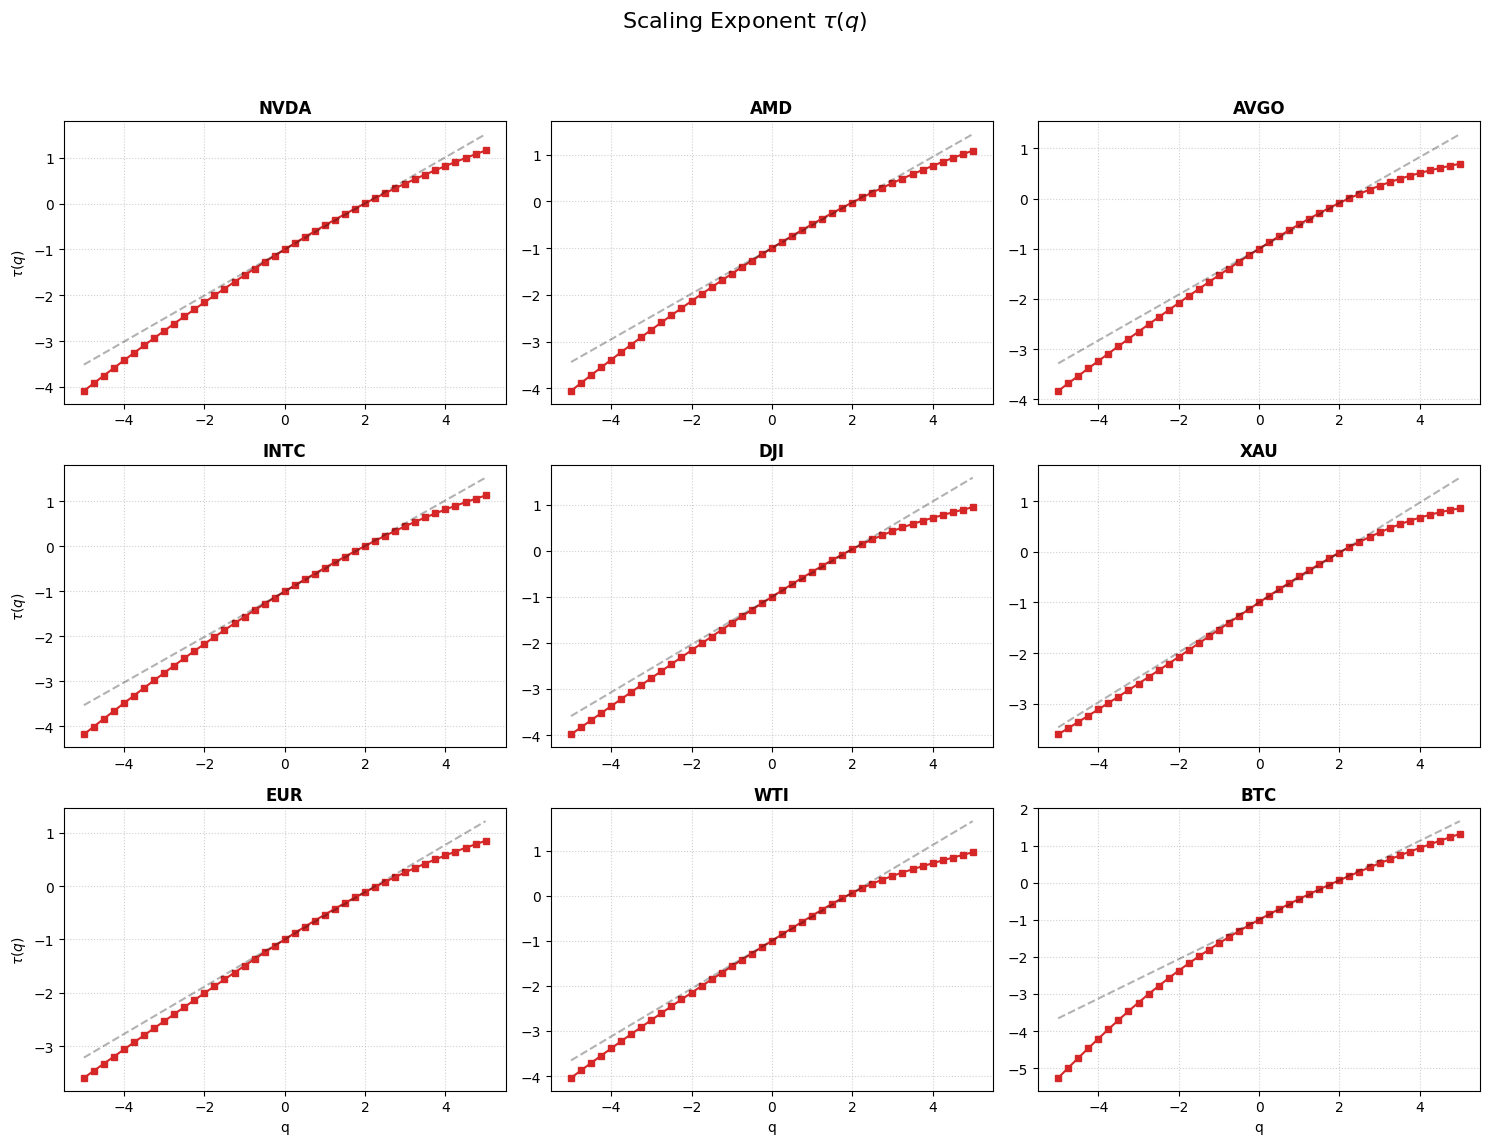

In [34]:
def mfdfa(series, q_list, scales, poly_order):
    X = series.values
    Y = np.cumsum(X - np.mean(X))
    N = len(Y)
    
    valid_scales = [int(s) for s in scales if N // s >= 2]
    
    if not valid_scales:
        return None, None
    
    F_q_s = np.zeros((len(q_list), len(valid_scales)))
    
    for i_s, s in enumerate(valid_scales):
        N_s = N // s
        F2_vals = []
        x_axis = np.arange(s)
        
        for v in range(N_s):
            idx_start = v * s
            y_seg = Y[idx_start : idx_start + s]
            p = np.polyfit(x_axis, y_seg, poly_order)
            resid = y_seg - np.polyval(p, x_axis)
            F2_vals.append(np.mean(resid**2))
            
            idx_start_b = N - (v+1) * s
            y_seg_b = Y[idx_start_b : idx_start_b + s]
            p_b = np.polyfit(x_axis, y_seg_b, poly_order)
            resid_b = y_seg_b - np.polyval(p_b, x_axis)
            F2_vals.append(np.mean(resid_b ** 2))
            
        F2_arr = np.array(F2_vals)
        F2_arr[F2_arr < 1e-10] = 1e-10
        
        for i_q, q in enumerate(q_list):
            if abs(q) < 1e-5:
                F_val = np.exp(0.5 * np.mean(np.log(F2_arr)))
            else:
                F_val = np.mean(F2_arr ** (q/2)) ** (1/q)
            F_q_s[i_q, i_s] = F_val
    
    return np.array(valid_scales), F_q_s

all_assets = semi_stock + financial_assets

q_points = [-5, -2, -0.2, 0.2, 2, 5]

q_range_full = np.linspace(-5, 5, 41)

min_scale = 20
max_scale = 240
scales = np.unique(np.logspace(np.log10(min_scale), np.log10(max_scale), 40).astype(int))
poly_order = 3

markers = ['v', 's', 'o', 'x', '^', 'D']
colors = plt.cm.viridis(np.linspace(0, 1, len(q_points)))

result = {}

for asset in all_assets:
    if asset not in log_returns.columns: continue
    data = log_returns[asset].dropna()
    if len(data) < 300: continue
    
    s_points, F_points = mfdfa(data, q_points, scales, poly_order)
    
    s_full, F_full = mfdfa(data, q_range_full, scales, poly_order)
    
    if s_full is None: continue
    
    log_s = np.log(s_full)
    h_q = []
    for i in range(len(q_range_full)):
        log_F = np.log(F_full[i, :])
        slope, _ = np.polyfit(log_s, log_F, 1)
        h_q.append(slope)
        
    h_q = np.array(h_q)
    tau_q = q_range_full * h_q - 1
    
    result[asset] = {
        's_points': s_points, 'F_points': F_points,
        'h_q': h_q, 'tau_q': tau_q
    }
  
fig1, axes1 = plt.subplots(3, 3, figsize=(15, 12))
fig1.suptitle('MF-DFA: Fluctuation Function $F_q(s)$ vs Scale $s$ (Log-Log)', fontsize=16)
axes1 = axes1.flatten()

for i, asset in enumerate(all_assets):
    ax = axes1[i]
    if asset not in result:
        ax.text(0.5, 0.5, 'No Data', ha = 'center')
        continue
    res = result[asset]
    s_vals = res['s_points']
    F_vals = res['F_points']
    
    for j, q in enumerate(q_points):
        ax.loglog(s_vals, F_vals[j, :],
                  marker = markers[j], linestyle = '-', linewidth = 1,
                  color = colors[j], label = f'q={q}' if i == 0 else "")
    ax.set_title(asset, fontweight = 'bold')
    ax.grid(True, which = 'both', linestyle = ':', alpha = 0.6)
    ax.set_xticks([20, 50, 100, 200, 300]) 
    ax.get_xaxis().set_major_formatter(ScalarFormatter()) 
    
    ax.get_yaxis().set_major_formatter(ScalarFormatter()) 

    if i >= 6: ax.set_xlabel('Scale $s$')
    if i % 3 == 0: ax.set_ylabel('$F_q(s)$')
    
fig1.legend(loc = 'lower center', ncol=len(q_points), bbox_to_anchor = (0.5, 0.0), frameon = True)
plt.tight_layout(rect = [0, 0.05, 1, 0.95])
plt.show()

fig2, axes2 = plt.subplots(3, 3, figsize=(15, 12))
fig2.suptitle('Generalized Hurst Exponent $h(q)$', fontsize=16)
axes2 = axes2.flatten()

for i, asset in enumerate(all_assets):
    ax = axes2[i]
    if asset not in result: continue
    
    h_vals = result[asset]['h_q']
    
    ax.plot(q_range_full, h_vals, 'o-', color='tab:blue', markersize=4)
    ax.axhline(0.5, color='gray', linestyle='--', label='Random Walk')
    
    ax.set_title(asset, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_ylim(0, 1.0) 
    
    if i >= 6: ax.set_xlabel('q')
    if i % 3 == 0: ax.set_ylabel('$h(q)$')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


fig3, axes3 = plt.subplots(3, 3, figsize=(15, 12))
fig3.suptitle('Scaling Exponent $\\tau(q)$', fontsize=16)
axes3 = axes3.flatten()

for i, asset in enumerate(all_assets):
    ax = axes3[i]
    if asset not in result: continue
    
    tau_vals = result[asset]['tau_q']
    
    ax.plot(q_range_full, tau_vals, 's-', color='tab:red', markersize=4)
    
  
    idx_q2 = np.argmin(np.abs(q_range_full - 2))
    h2 = result[asset]['h_q'][idx_q2]
    linear_fit = q_range_full * h2 - 1
    ax.plot(q_range_full, linear_fit, 'k--', alpha=0.3, label='Monofractal Fit')

    ax.set_title(asset, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)
    
    if i >= 6: ax.set_xlabel('q')
    if i % 3 == 0: ax.set_ylabel('$\\tau(q)$')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
